# Modelling Solid State batteries

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib tk

import sys
sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonicTesting/')
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonic_ml/src/')

import ultrasonic_ml.models.tmm_np as tmm
import numpy as np

import pandas as pd

tk max_figwidth: 20.17913385826772


## Experimental setup:

* [Notion page and relevant info](https://app.notion.com/p/chang-lab/Chemo-mechanics-of-sulfide-silicon-solid-state-ceec188812b141448f76f68e4e6b7e70)
   * [Lit review](https://app.notion.com/p/chang-lab/Literature-review-d4dcd386b89242d5a4a8305d39bde021?source=copy_link)
   * [Physical properties with UT](https://app.notion.com/p/chang-lab/Quantification-of-cell-physical-properties-with-ultrasonic-signals-Task-ID-2-4b239f33fdee4442897318bbec11bbcb?source=copy_link)
   * [Prelim Acoustic](https://app.notion.com/p/chang-lab/Preliminary-acoustic-data-4f3e5f77d60449ed877a3f41ecae7f53?source=copy_link)
   * [pressures, temperatures LPSCl and PVDF concentration](https://app.notion.com/p/chang-lab/Determine-impact-of-electrolyte-microstructure-on-acoustic-signals-1248603a8ec680d3a5d5e2ad16a9de06?source=copy_link)
   * [Determine mechanical Poissons Ratio, Youngs Modulus, Shear Modulus of LPSCl](https://app.notion.com/p/chang-lab/Determine-mechanical-Poissons-Ratio-Youngs-Modulus-Shear-Modulus-of-LPSCl-d60b9f4ba7e140c78fd6ba8b454b558b?source=copy_link)
* Help with these:
    * [decouple electrode UT](https://app.notion.com/p/chang-lab/Systematic-decoupling-of-individual-electrode-effects-on-overall-ultrasonic-signal-Task-ID-3-aa1b107cdea84cdfaf4745e3da12575f?source=copy_link)
    * [varying stack pressure](https://app.notion.com/p/chang-lab/Comparison-of-cell-physical-changes-across-a-wide-range-of-stack-pressures-Task-ID-5-d07c0b41ff53404e9dcb22cd3233a566?source=copy_link)
    * [modeling silicon lithiation](https://app.notion.com/p/chang-lab/Modeling-silicon-lithiation-mechanics-with-sulfides-under-varying-processing-conditions-29ec44721150485d94a93a3f3a5d8aa3?source=copy_link)
    * [Simple modeling to understand ToF changes in full cell](https://app.notion.com/p/chang-lab/Simple-modeling-to-understand-ToF-changes-in-full-cell-2a28603a8ec6801f8672dfc2f13ab528?source=copy_link)
    

<img src="ss_stack.png" width="400"/>

- Transducers: 2.25 MHz (longitudinal) ​
- Couplant: nitrile, NBR, and acrylonitrile butadiene (BNR – McMaster Carr). Electronically insulating ​
- Repeat pulse collecting every 30 seconds ​
- Testing inside a temperature chamber ​
- Assumptions: ​
    - Using rule of mixtures for anode ​
    - Using rule of mixtures for cathode​
    - E and density of electrolyte, carbon, binder, current collectors does not change during cycling ​
    - Homogeneous, isotropic, linear elastic, and continuous ​
    - Interface between the different components have the same properties as the bulk ​v

Fatima's pptx: [Ford - Dec 2025](https://drexel0.sharepoint.com/:p:/r/sites/ChangLab/_layouts/15/Doc.aspx?sourcedoc=%7B84F84037-9208-4FB0-9E6E-A4A7BDC5C363%7D&file=Ford%20-%20Dec%202025.pptx&action=edit&mobileredirect=true)
- look into citations for Si, NMC

My pptx: [2026-7-16-TRINA](https://drexel0.sharepoint.com/:p:/r/sites/ChangLab/Shared%20Documents/General/Individual/Xinqiao%20Zhang/Slides/2026-7_16_TRINA.pptx?d=wa4f000b988c54e699eb874b4affb6f58&csf=1&web=1&e=MXSGSB)

LSPCl
- [MSE supplies](https://www.msesupplies.com/products/ampcera-argyrodite-li6ps5cl-sulfide-solid-electrolyte-ultra-fine-powder-d50-2-3-um?utm_source=google&utm_medium=cpc&utm_campaign=21503213167&utm_term=&gad_source=1&gad_campaignid=21503213167&gbraid=0AAAAADd9Nn_nx54-KEefwCwcDvmv6-Ipl&gclid=CjwKCAjw1vXTBhB-EiwAEKr_k_XbFb6dYrHT4CA9Vyk4OOaccTWYdjo4u5EG7bynFVBkpj9XI-UP-hoCVTgQAvD_BwE&variant=23379283902522)
- [First-Principles Investigation of Mechanical Properties and Anisotropy of Argyrodite Li6PS5Cl Crystal Electrolytes](https://pubs.acs.org/jpccck/article/129/39/17882/3740509/First-Principles-Investigation-of-Mechanical)


couplant:
- [Oil-Resistant Buna-N Rubber Sheet, 12" x 12", 3/32" Thick, 50A Durometer](https://www.mcmaster.com/products/nitrile-rubber-sheets/thickness~3-32/width~12/width~1-ft/backing-type~plain/length~12/length~1-ft/hardness~durometer-50a/?s=nitrile-rubber-sheets)
- [Stability-Constrained Hyperelastic Calibration of Nitrile Butadiene Rubber Using Multi-Mode Experiments, Genetic Algorithm Optimization, and Finite Element Analysis
](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=7347049)
- 

Steel
- [T300 Stainless Steel](https://www.matweb.com/search/DataSheet.aspx?MatGUID=7a87941825a3463eaba7979c4333721f)

Copper


Calculating mechanical properties:
- [Convert Elastic Modulus Constants (Shear, Young’s, Bulk)](https://www.mydatabook.org/solid-mechanics/convert-elastic-modulus-constants-shear-youngs-bulk/): starting point. Go find textbook
- NOTE: usually you need to use bulk modulus for speed of sound calculations, however, in thin films and fibers where there is freedom to expand, elastic modulus in the direction of longitudinal sound wave can be used. look at the old article. [Young's Modulus of Elasticity of Fibers and Films by Sound Velocity Measurements](https://pubs.aip.org/asa/jasa/article-abstract/16/2/113/646765/Young-s-Modulus-of-Elasticity-of-Fibers-and-Films?redirectedFrom=fulltext)

## Parameters calculations:
TODO: Eventually, we wnat in this format, w conversion functions for better readability:
* $c$ — sound velocity [m/s]
* $ρ$ — density [kg/m³]
* $Z = ρ·c$ — acoustic impedance [MRayl / GRayl, N*s/m^3]
* $E= c^2 * ρ$ - elastic modulus (but others can be used interchangeably? in the case of thin films and fibers)
    * $K = c^2 * ρ$ — bulk modulus [GPa]
    * $E = 3K(1 - 2ν)$ - elastic modulus [GPa]
    * $ν$ - Poisson's ratio
* d — thickness [µm]
* n — number of layers of that component in the original cell

For now, just use SI units so its less confusing

In [2]:
params = tmm.params

# tmm

## theory: normal acoustic propagation/ reflection in layered stack
- Feiler, S., Gold, L., Hartmann, S., & Giffin, G. A. (2025). Modeling acoustic attenuation, sound velocity and wave propagation in lithium‐ion batteries via a transfer matrix. Batteries & Supercaps, 8(3), e202400478.
- Byrnes, S. J. (2016). Multilayer optical calculations. arXiv preprint arXiv:1603.02720.
- [to read- tmm for extimating dispersion](https://docs.lib.purdue.edu/cgi/viewcontent.cgi?article=1054&context=herrick)

Using modified notation from Feiler paper for clarity.

- Acoustic waveform $\psi_i$ enters a stack of materials $M_n$. Here, layer 0 and 4 are coupled to the transducer and we assume there is no reflective interface.
    $$\psi_i \rightarrow  M_0 | M_1 | M_2 | M_3 | M_4 $$

    - $P_{M_n}$ is the propagation matrix through material $M_n$ 
        $$
        P_{M_n} =
        \begin{bmatrix} 
            e^{(ik_{M_n} - \alpha_{M_n}) d_{M_n}} & 0 \\ 
            0 &  e^{-(ik_{M_n} - \alpha_{M_n}) d_{M_n}} 
        \end{bmatrix}
        $$
        - $d_{M_n}$ is the layer thickness
        - $\alpha_{M_n}$ is the attenuation coefficient of medium
        - ${c_{M_n}}$ is the speed of sound through the medium
        - $k_{M_n}$ is the wavenumber defined as: $$k_{M_n} = \frac{2\pi}{\lambda} =\frac{2\pi}{c_{M_n}}$$
    - $D_{M_n,M_m}$ is the interface matrix while travelling from $M_n$ to $M_m$
        $$
        D_{M_n,M_m} = \frac{1}{t_{M_n,M_m}}
        \begin{bmatrix} 
            1 & r_{M_n,M_m} \\ r_{M_n,M_m} &  1 
        \end{bmatrix}
        $$
        - $r_{M_n,M_m}$ is the reflection coefficient travelling from $M_n$ to $M_m$, defined as: 
            $$r_{M_n,M_m} = \frac{Z_{M_m} - Z_{M_n}}{Z_{M_n} + Z_{M_m}}$$
        - $t_{M_n,M_m}$ is the transmission coefficient travelling from $M_n$ to $M_m$, defined as:
            $$t_{M_n,M_m} = \frac{2Z_{M_m}}{Z_{M_n} + Z_{M_m}}$$
        - $Z_{M_n}$ is the acoustic impedance defined as: $Z_{M_n} = \rho_{M_i}c_{M_i}$

- The full stack would be constructed as:
    $$
    \begin{bmatrix} \psi_{i,r} \\ \psi_{i,l} \end{bmatrix}
    =P_{M_0}D_{M_0,M_1} P_{M_1}D_{M_1,M_2} P_{M_2}D_{M_2,M_3} P_{M_3}D_{M_3,M_4} P_{M_4}...D_{M_{N-1},M_N} P_{M_N}
    \begin{bmatrix} \psi_{f,r} \\ \psi_{f,l} \end{bmatrix}
    $$
    - **Boundary conditions:**
        - $\psi_{i,r}$ is our input wave, as a numpy array. 
        - $\psi_{i,l}$ is unknown. This represents our reflected wave
        - $\psi_{f,r}$ is unknown. This represents our transmitted wave
        - $\psi_{f,l}$ is 0. This is under the assumption that the last layer extends infinitely. 
            - This might not be a good assumption. We may need the acoustic properties of the clamp or transducers to use as the last layer if they contribute to the waveform significantly.
            - Alternatively, we can have a material at the end of the stack the guides the pulse away from the sample. Like an angled block. 

- The final waveform is related to the initial through the transfer matrix 
    $$\psi_i = T \psi_f$$
    $$
    \begin{bmatrix} \psi_{i,r} \\ \psi_{i,l} \end{bmatrix}
    =
    \begin{bmatrix} T_{11} & T_{12} \\ T_{21} & T_{22} \end{bmatrix}
    \begin{bmatrix} \psi_{f,r} \\ \psi_{f,l} \end{bmatrix}
    $$

- $(\psi_{f,r},\psi_{f,l})$ are the final right and left moving waveforms, and  $(\psi_{i,r},\psi_{i,l})$ are the initial.

- $T$ is the transfer matrix constructed from multiplying the propagation and interfaces together. We can now solve the system of equations
    $$
    \begin{bmatrix} \psi_{i,r} \\ \psi_{i,l} \end{bmatrix}
    = \begin{bmatrix} T_{11} & T_{12} \\ T_{12} & T_{22} \end{bmatrix}
    \begin{bmatrix} \psi_{f,r} \\ \psi_{f,l} \end{bmatrix}
    $$
    - Transmission, where the transmission coefficient can be expressed as $T(k) = 1/T_{11}$: 
        $$\psi_{f,r} = \frac{1}{T_{11}} \psi_{i,r}$$
    - Reflection, where the reflection coefficient can be expressed as  $R(k) = T_{12}/T_{11}$: 
        $$\psi_{i,l} = \frac{T_{12}}{T_{11}} \psi_{i,r}$$

- If your input signal contains multiple frequencies (such as our morlet), you need to calculate the transfer matrix at every frequency since the behavior depends on the wavenumber $k=2\pi f/c$:
    - take fft of morlet input
    - calculate transfer matrix $T$ at every frequency. If this is too expensive, we can threshold which bins to use
    - calculate $(\psi_{f,r}, \psi_{i,l})$ in frequency domain and apply ifft to get back to time domain.

- when using FFT transform, there will be signal at both $(\pm f)$.
    - $T(-f) = T(f)^*$ because both the propagation and interface matrices are symmetric. (ie $P_{M_n}(-f) = P_{M_n}(f)^*$ and $D_{M_n,M_m}$ is not frequency dependent)

## Layer by Layer representation

In [3]:
import ultrasonic_ml.models.tmm_np as tmm
import scipy.signal as signal

### full stack:

In [4]:
n = 1
layer_list = ['Cu', 'Si', "Li_6 P S_5 Cl", "Li Ni_0.6 Mn_0.2 Co_0.2 O_2"] # just trying with one layer of battery rn

stack = [
    'Buna-N 50A',
    'Steel_bottom',
] + layer_list * n + [
    'Steel_top',
    'Buna-N 50A',
]

layers_df = tmm.construct_stack_df(stack)

In [5]:
# tmm.plot_layers(layers_df)

In [6]:
layers_df = layers_df[
    [col for col in layers_df.columns if col != "name_mpl"] + ["name_mpl"]
]

tmm.style_stack_df(layers_df)

,name,density,E,thickness,attenuation,sound_speed,Z,wavelength,name_mpl
0,Buna-N 50A,1.17e+03,1.35e+09,2.38e-03,0.00e+00,1.07e+03,1.26e+06,4.77e-04,Buna-N 50A
1,Steel_bottom,7.85e+03,1.95e+11,2.48e-02,0.00e+00,4.98e+03,3.91e+07,2.22e-03,Steel_bottom
2,Cu,8.96e+03,1.10e+11,1.00e-02,0.00e+00,3.50e+03,3.14e+07,1.56e-03,Cu
3,Si,2.30e+03,1.51e+11,5.00e-03,0.00e+00,8.11e+03,1.86e+07,3.60e-03,$\mathrm{Si}$
4,Li_6 P S_5 Cl,1.64e+03,2.74e+10,1.00e-02,0.00e+00,4.09e+03,6.70e+06,1.82e-03,$\mathrm{Li_{6}PS_{5}Cl}$
5,Li Ni_0.6 Mn_0.2 Co_0.2 O_2,4.76e+03,1.70e+11,5.00e-03,0.00e+00,5.98e+03,2.84e+07,2.66e-03,$\mathrm{LiNi_{0.6}Mn_{0.2}Co_{0.2}O_{2}}$
6,Steel_top,7.85e+03,1.95e+11,4.04e-02,0.00e+00,4.98e+03,3.91e+07,2.22e-03,Steel_top
7,Buna-N 50A,1.17e+03,1.35e+09,2.38e-03,0.00e+00,1.07e+03,1.26e+06,4.77e-04,Buna-N 50A


#### step by step

In [7]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,60000-2000) * dt
f0 = 2.25e6
t0 = 0
sigma = 0.25e-6


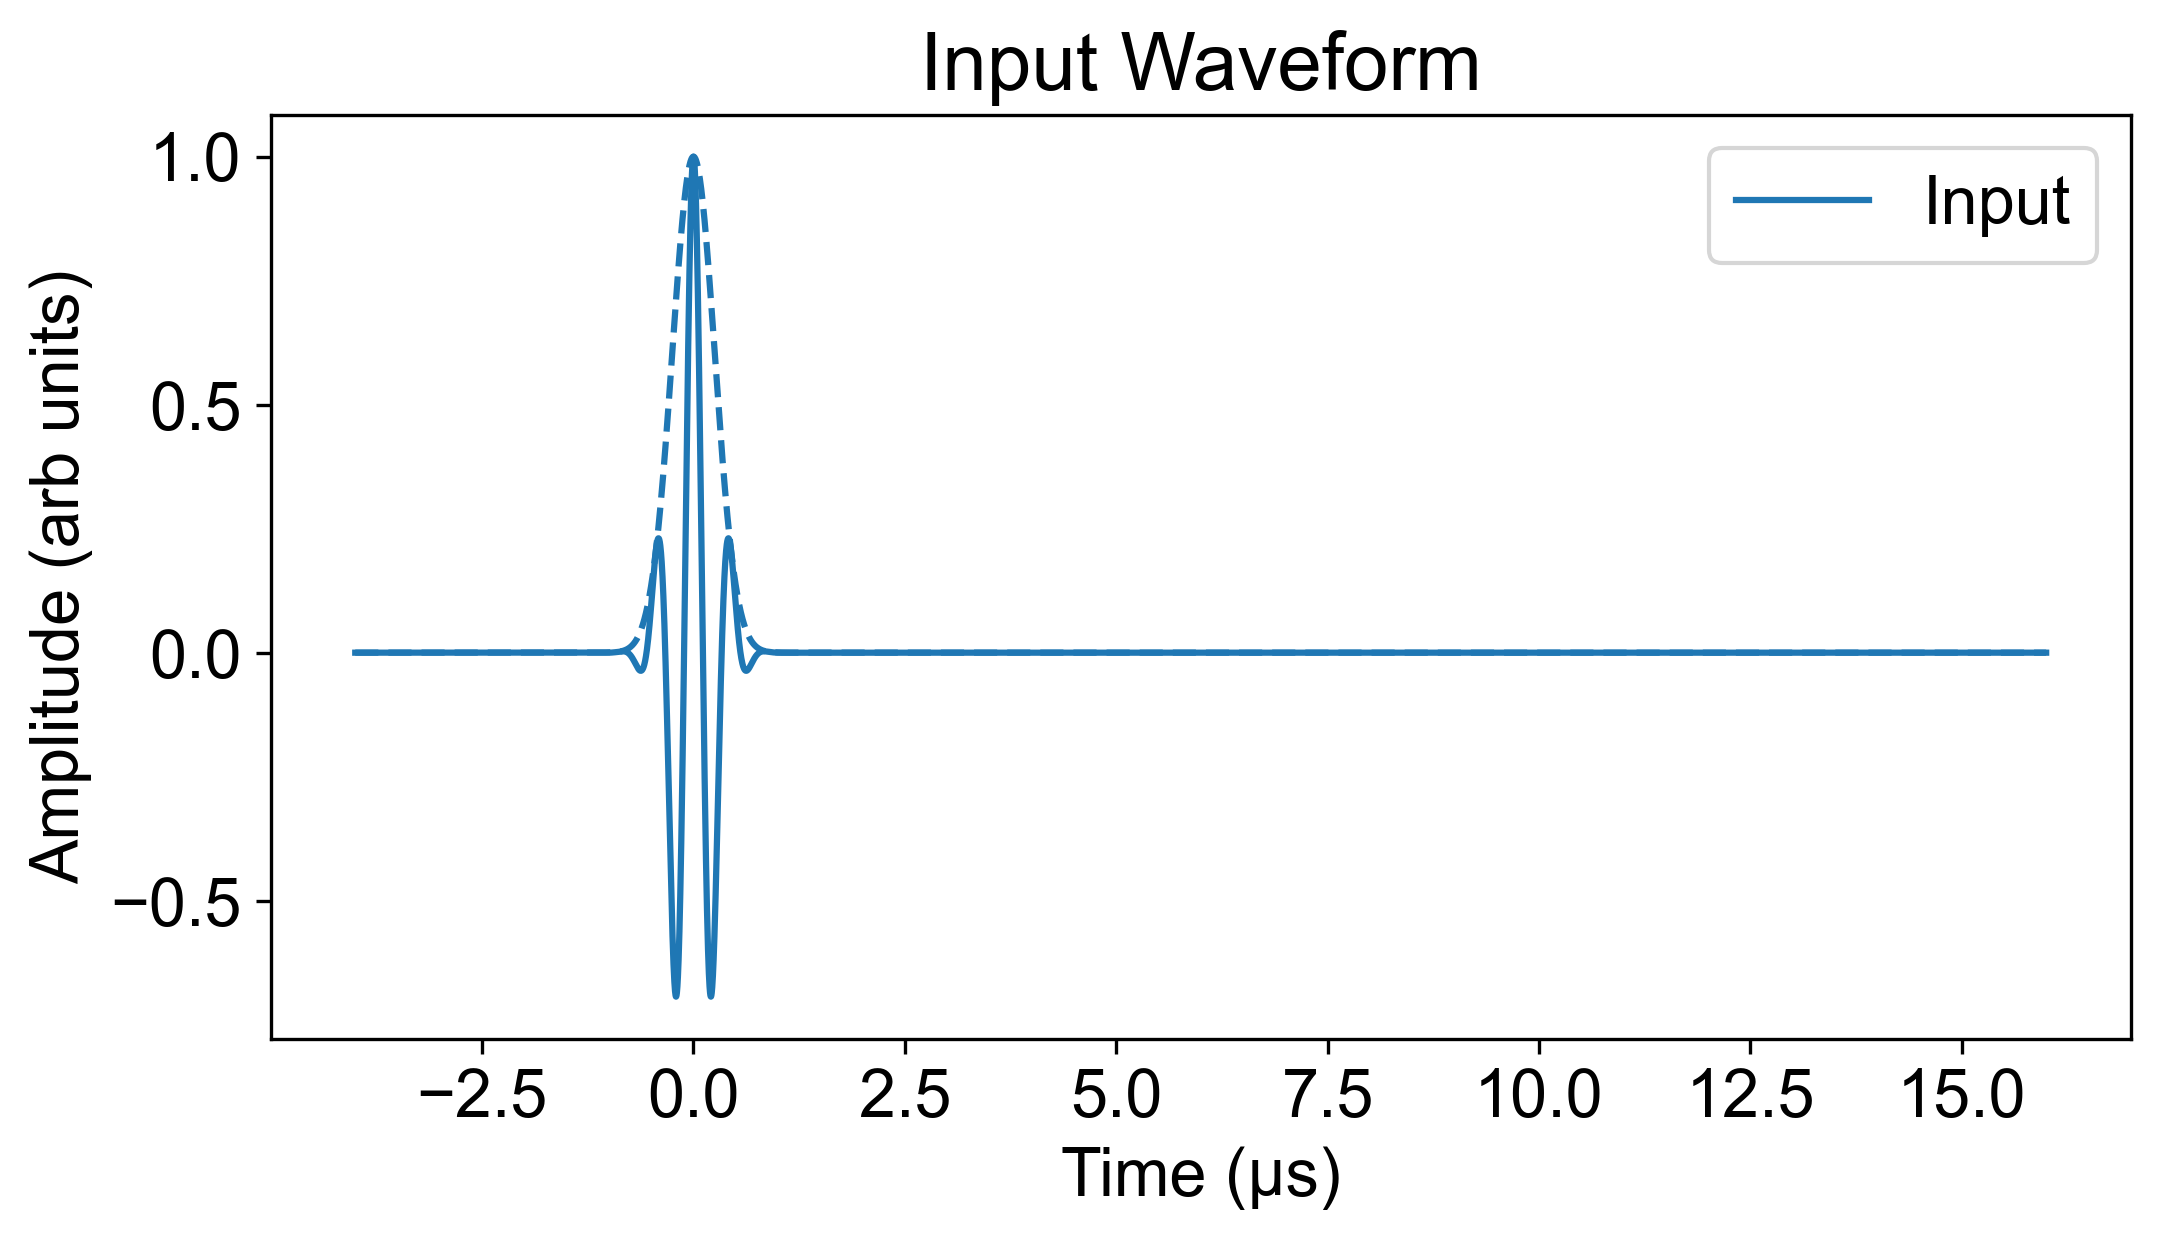

In [8]:
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

crop = slice(0, 10000)
fig,ax = plt.subplots(figsize=(8,4))
ax = tmm.plot_waveforms((t*1e6)[crop], [input_waveform[crop]], [input_envelope[crop]], 
                        labels=['Input'], ax=ax, title="Input Waveform", x_label="Time (μs)", y_label="Amplitude (arb units)")

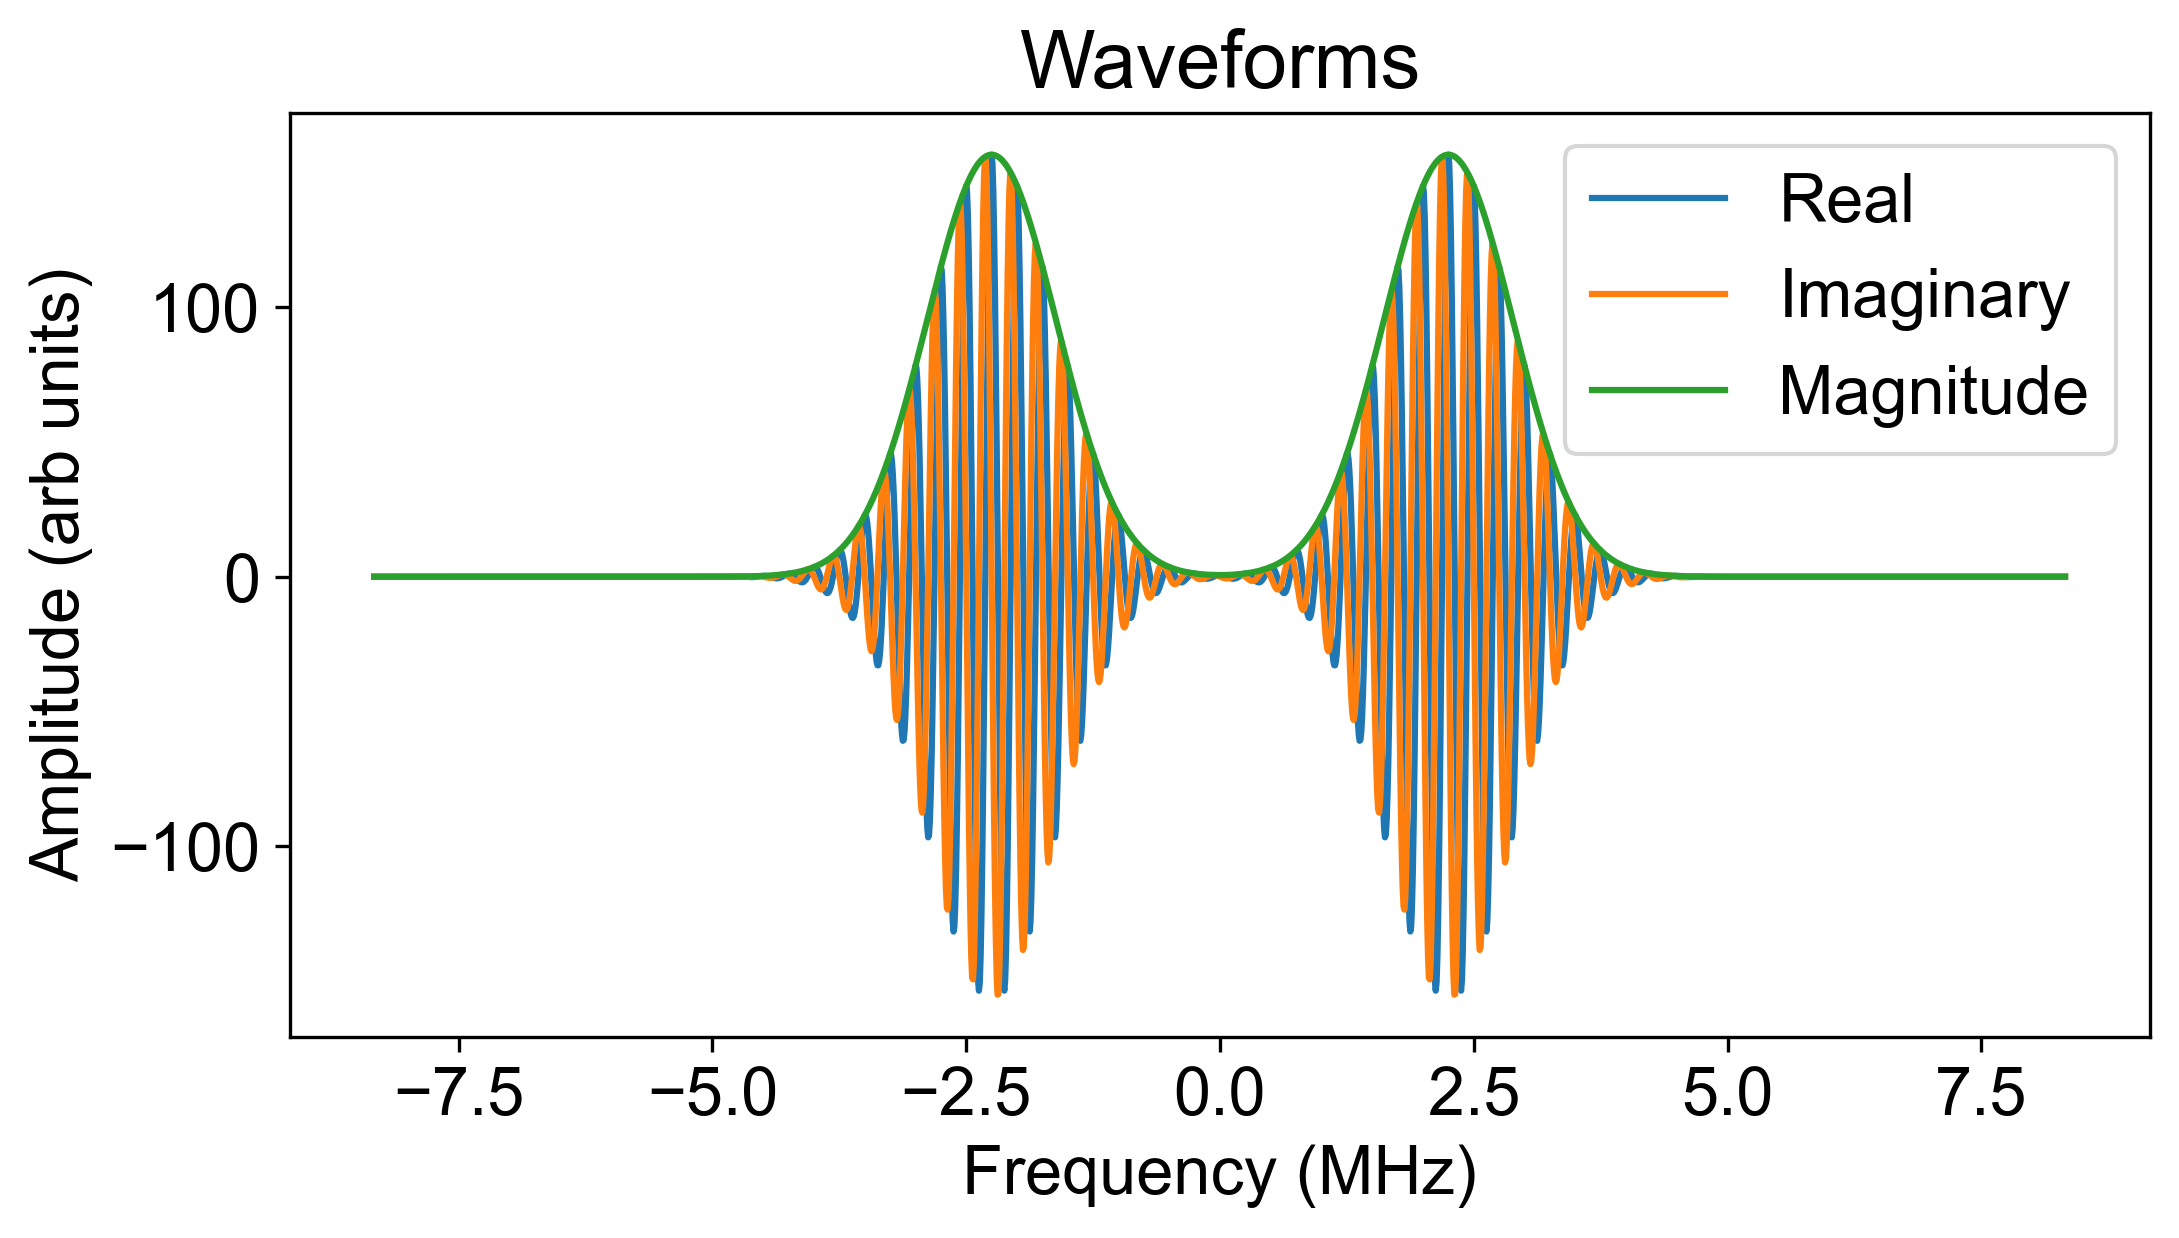

In [9]:
fft_ = np.fft.fftshift(np.fft.fft(input_waveform))
freqs = np.fft.fftshift(np.fft.fftfreq(len(t), dt))
crop = slice(len(freqs)//2-1000, len(freqs)//2+1000)

fig,ax = plt.subplots(figsize=(8,4))
ax = tmm.plot_waveforms(freqs[crop]/1e6, 
                        [np.real(fft_[crop]), np.imag(fft_[crop]), np.abs(fft_[crop])],
                        labels=['Real', 'Imaginary', 'Magnitude'], 
                        x_label="Frequency (MHz)", y_label="Amplitude (arb units)", 
                        ax=ax)

### discretizing time signal: padding and phase shift to center signal
Additionally, there are complication when it comes to discretizing the signal. Consider that the time axis is partially negative and we need to apply a phase shift. 
(based on (this)[https://brianmcfee.net/dstbook-site/content/ch06-dft-properties/Shifting.html] theory and (this)[https://app.notion.com/p/chang-lab/3dc8603a8ec680529706c5e31bc19ae3?v=3dc8603a8ec680db9714000c9264bde8&p=3dc8603a8ec680d79318d0fb7bd7e53a&pm=s] post on stack exchange)

The discrete fourier transform is:
$$X[k] = \sum _{n=0} ^{N-1} x[n] e^{−\frac{j 2\pi k n}{N}}$$
- $X[k]$ is the DFT
- $k=2\pi f/c$ is the wavenumber
- $N$ is the number of samples (number of timesteps)
Separate the magnitude ($A(k)$) and angle ($\phi(k)$), and you get for each wavenumber($k$):
$$X[k] = A_k * e^{j \phi _k}$$

Now suppose there was a time delay by $d$ points. Aka, the time is 0 at position $d$ in the time axes. We need to define a new function to represent the shifted waveform and DFT in terms of the old.
- assume that shifting is circular. So $y[n] = x[n-d$ mod $N]$, shortened to $y[n] = x[n-d]$
- $Y[n]=FFT(y[n])$
- let $m = n-d$
$$Y[k] = \sum _{n=0} ^{N-1} y[n] e^{−\frac{j 2\pi kn}{N}} = \sum _{n=0} ^{N-1-d} x[n-d] e^{−\frac{j 2\pi kn}{N}}$$
$$Y[k] = \sum _{m=-d} ^{N-1-d} x[m] e^{−\frac{j 2\pi k(m+d)}{N}} = \sum _{m=-d} ^{N-1-d} x[m] e^{−\frac{j 2\pi k(m)}{N}} e^{−\frac{j 2\pi k(d)}{N}}$$
$$Y[k] = e^{−\frac{j 2\pi k (d)}{N}} \sum _{m=-d} ^{N-1-d} x[m] e^{−\frac{j 2\pi k(m)}{N}} = e^{−\frac{j 2\pi k (d)}{N}} \sum _{m=-d} ^{N-1-d} x[m] e^{−\frac{j 2\pi k(m)}{N}} $$
Finally, if we have a "circular" shift:
$$Y[k] = e^{−\frac{j 2\pi k (d)}{N}} X[k]$$

However... if we do not have a circular shift, we will need to pad zeros at the beginning or end, perform our TMM calculations, the crop off the "wrapped around" portion of the signal. We will need to test several pad lengths to see how much is enough to prevent interference with the ΤΜΜ signal. In either case, we will shift enough 


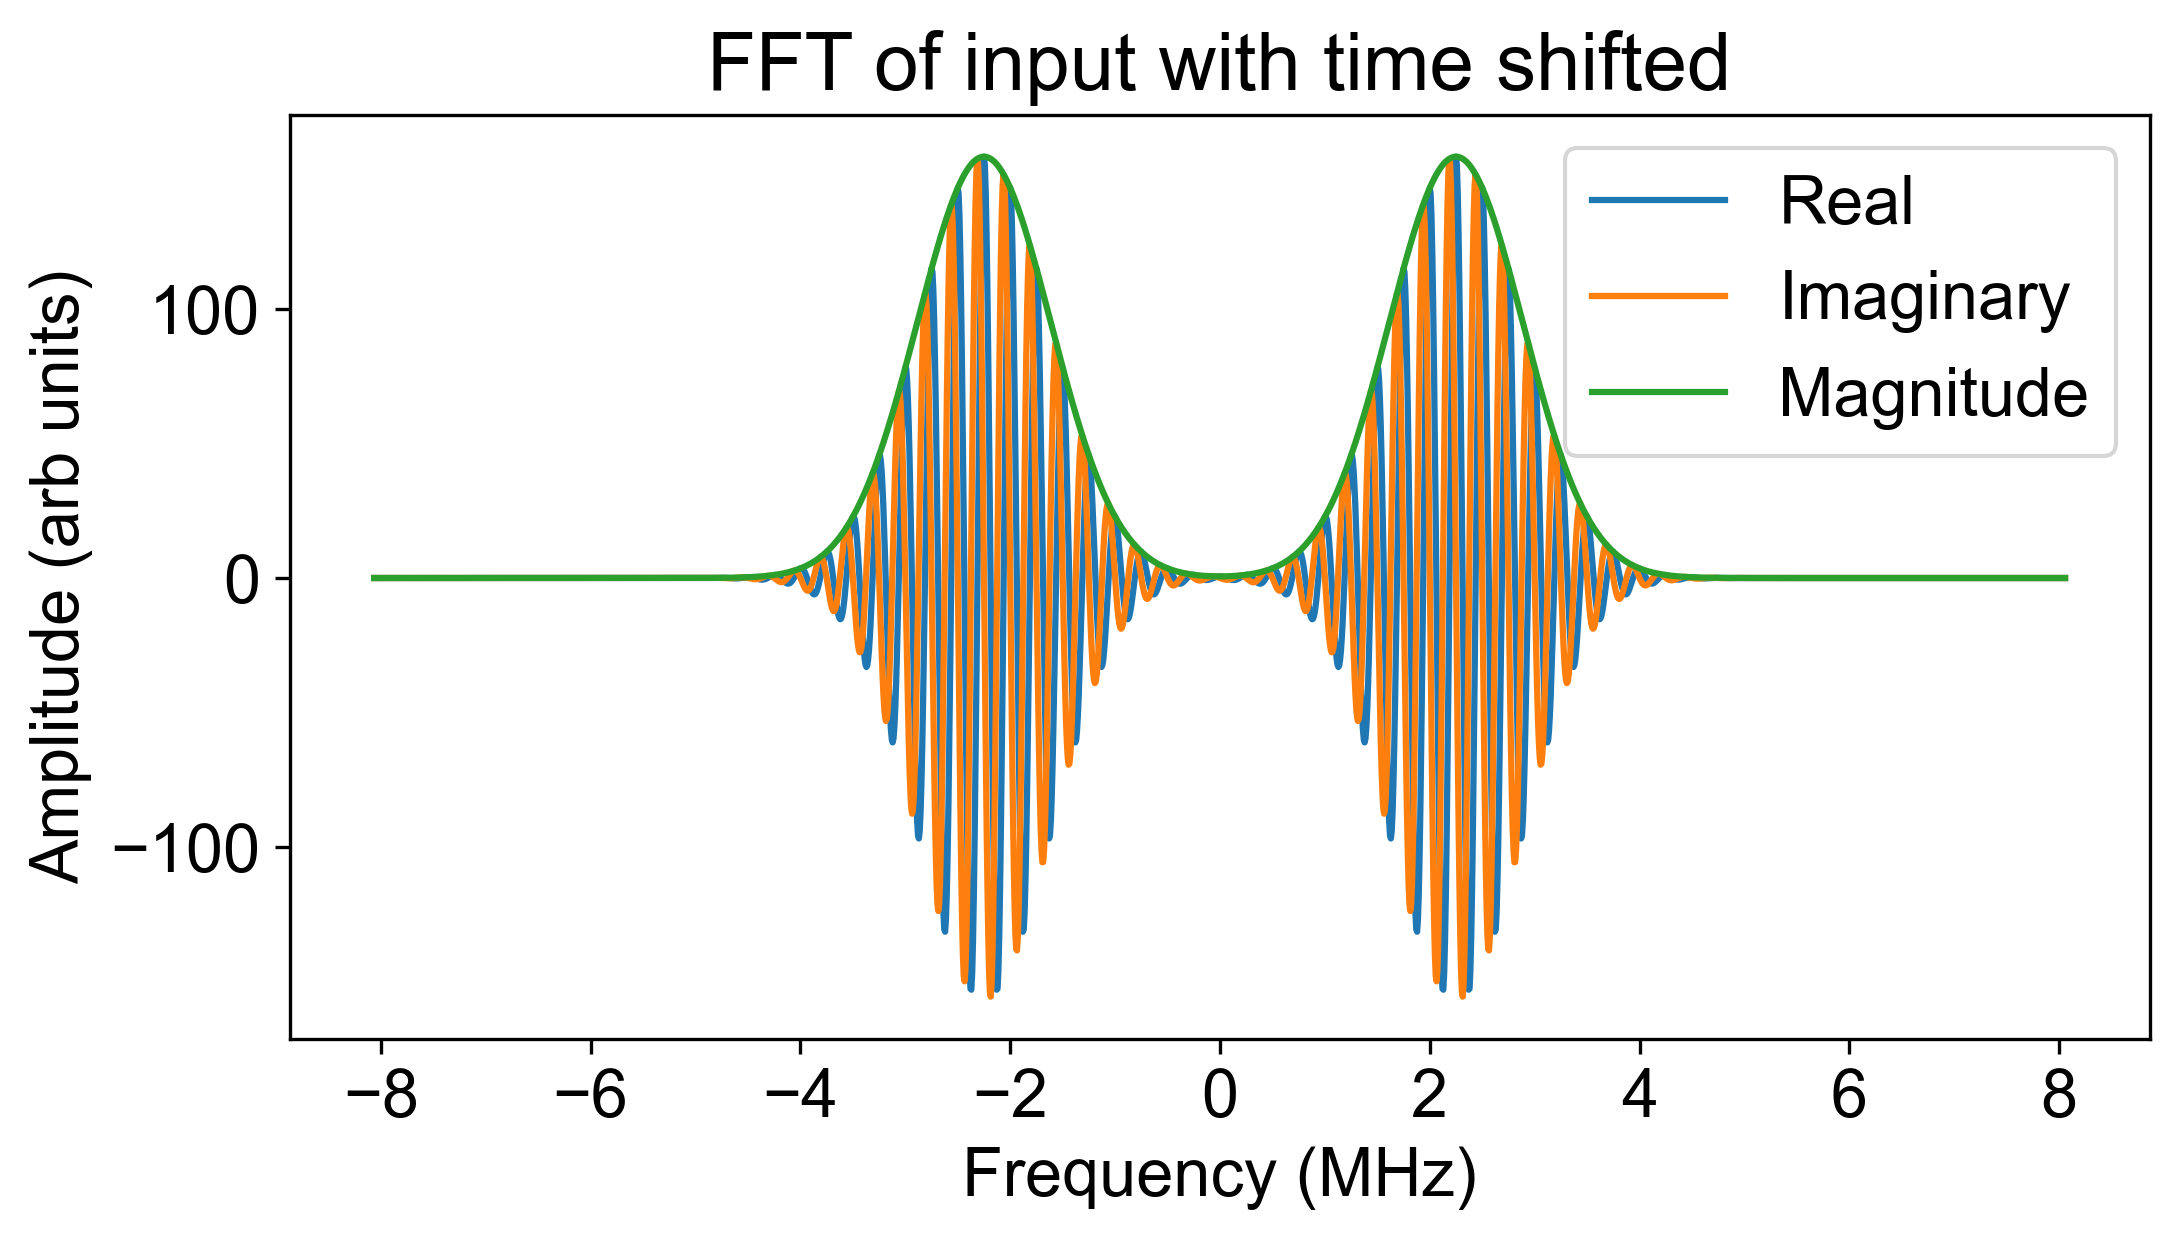

In [10]:
# but consider that the time axis is partially negative and need to apply a phase shift
freqs_shifted, fft_shifted = tmm.fft_phase_shifted(t, input_waveform, dt,
                                    beginning_pad_zeros=2000, end_pad_zeros=0)
freqs_shifted,fft_shifted = np.fft.fftshift(freqs_shifted), np.fft.fftshift(fft_shifted)

crop = slice(len(freqs_shifted)//2-1000, len(freqs_shifted)//2+1000)

fig,ax = plt.subplots(figsize=(8,4))
ax = tmm.plot_waveforms(freqs_shifted[crop]/1e6, 
                        [np.real(fft_shifted[crop]), np.imag(fft_shifted[crop]), np.abs(fft_shifted[crop])],
                        labels=['Real', 'Imaginary', 'Magnitude'], 
                        x_label="Frequency (MHz)", y_label="Amplitude (arb units)", 
                        ax=ax, title='FFT of input with time shifted')

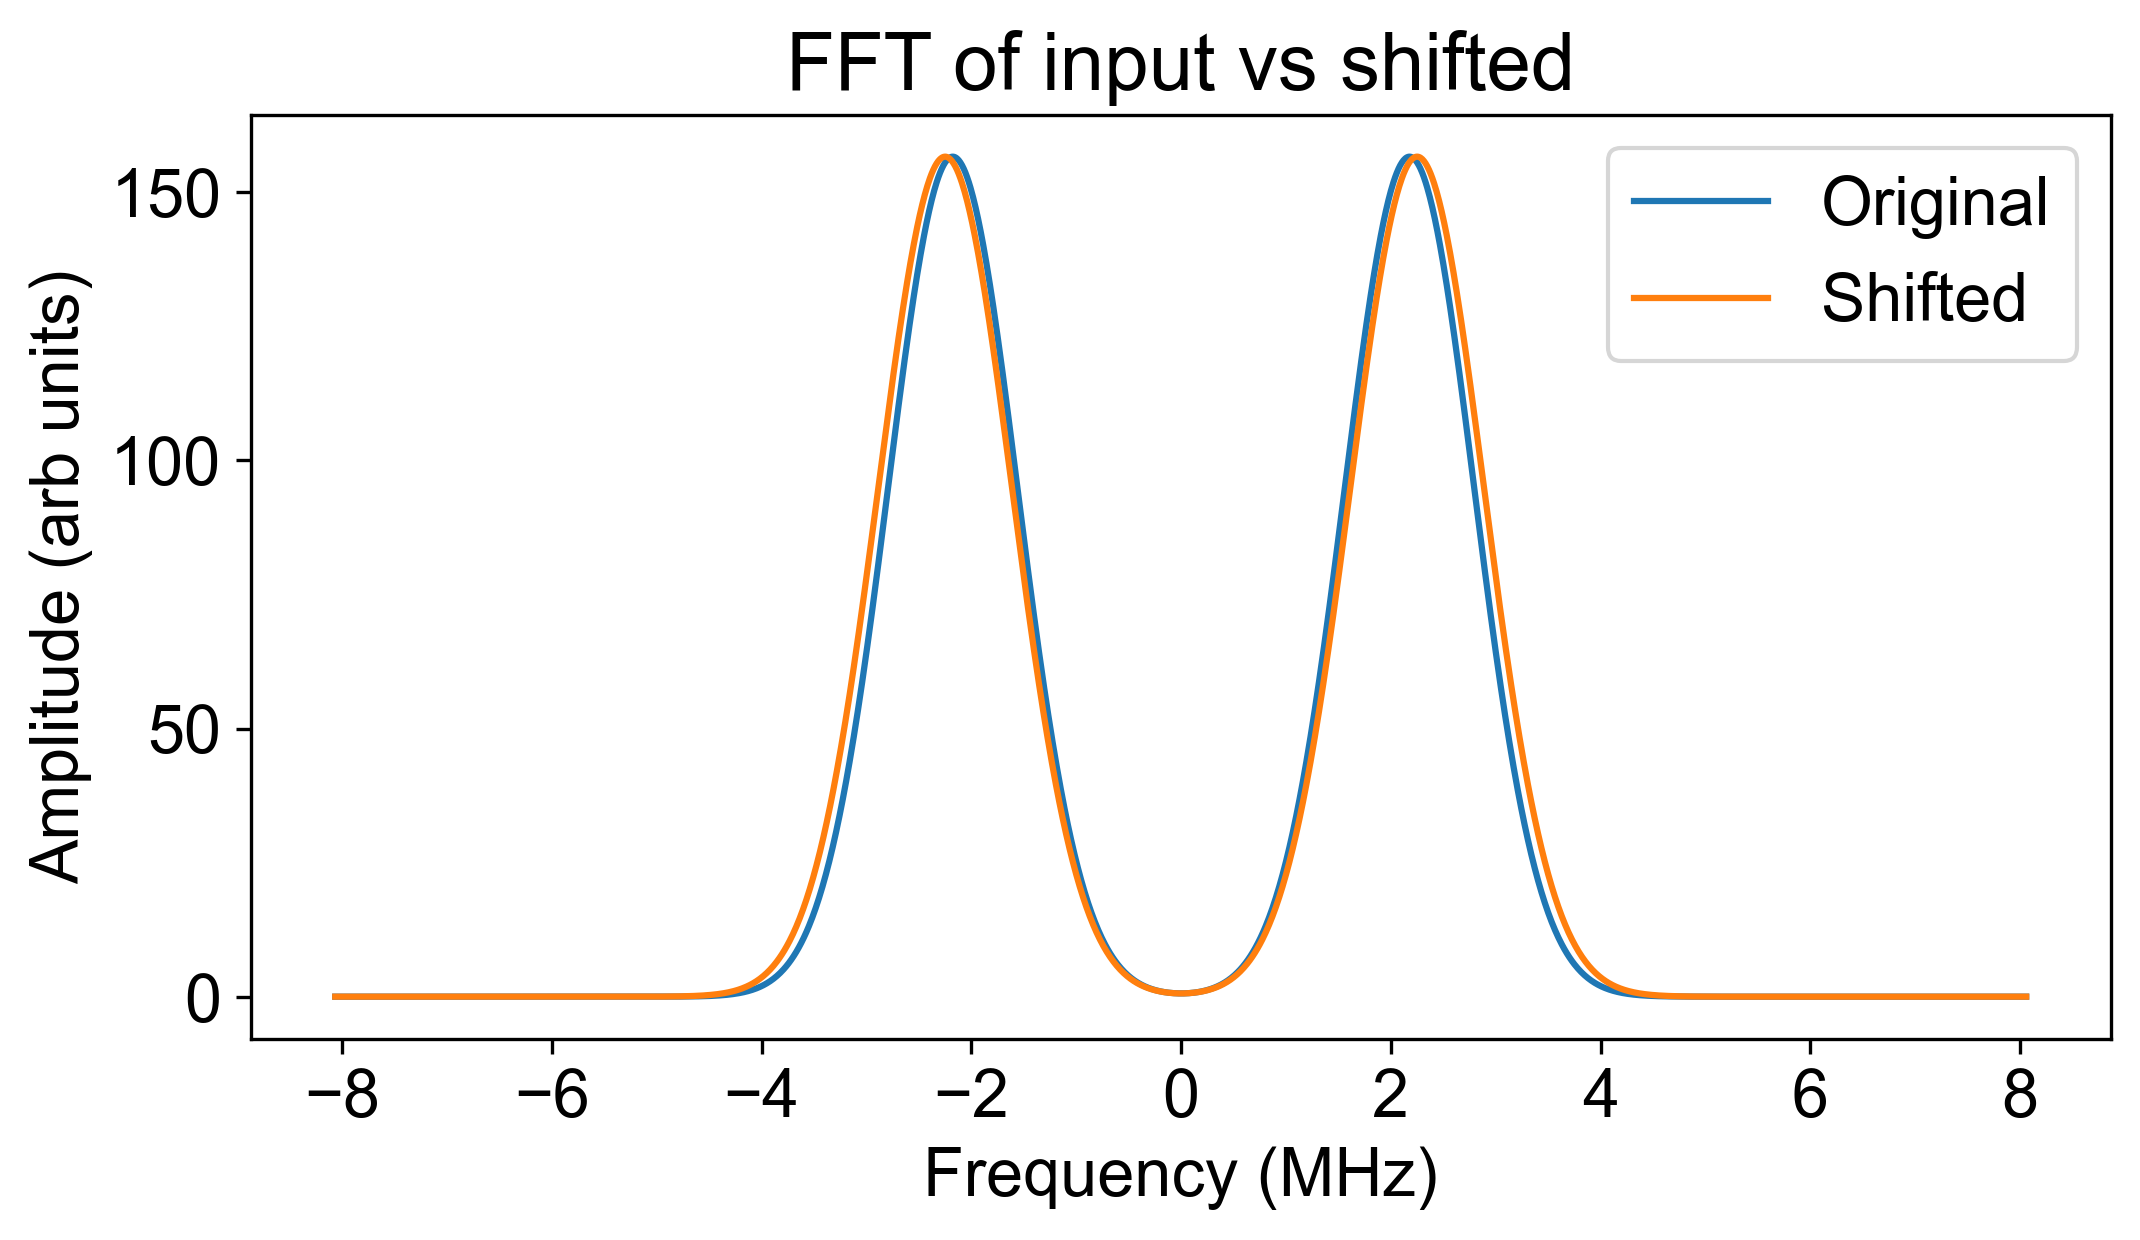

In [11]:
# but consider that the time axis is partially negative and need to apply a phase shift
crop_shifted = slice(len(freqs_shifted)//2-1000, len(freqs_shifted)//2+1000)
crop = slice(len(freqs)//2-1000, len(freqs)//2+1000)

fig,ax = plt.subplots(figsize=(8,4))
ax = tmm.plot_waveforms(freqs_shifted[crop_shifted]/1e6, 
                        [np.abs(fft_[crop]), np.abs(fft_shifted[crop_shifted])],
                        labels=['Original', 'Shifted'], 
                        x_label="Frequency (MHz)", y_label="Amplitude (arb units)", 
                        ax=ax, title='FFT of input vs shifted')

/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


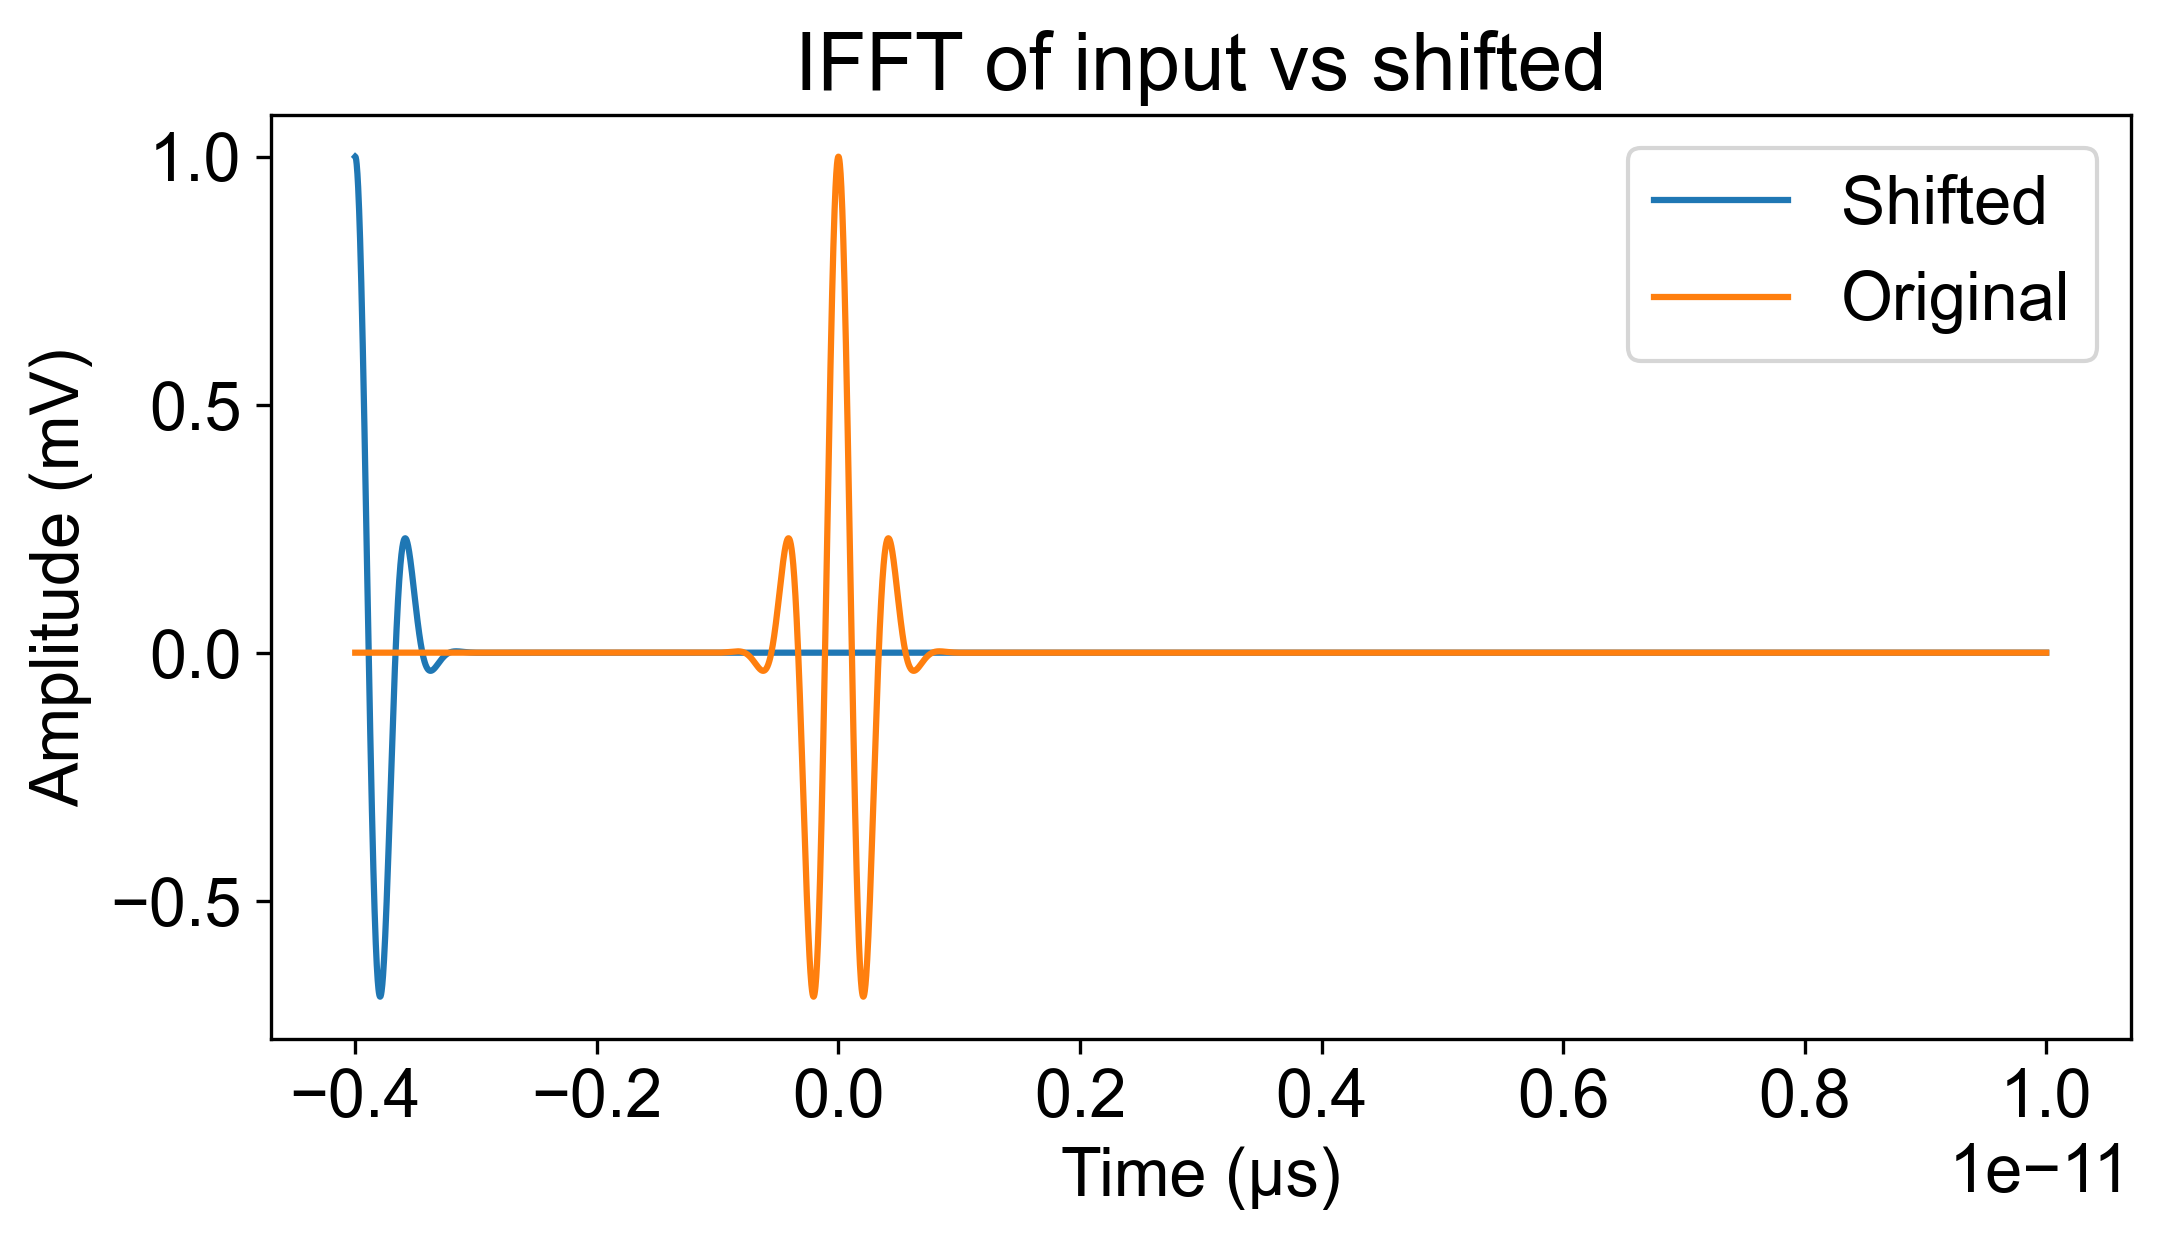

In [17]:
# sanity check that the ifft of the input is not centered on the first index of time axis.
ifft_ = np.fft.ifft(np.fft.ifftshift(fft_))
ifft_shifted = np.fft.ifft(np.fft.ifftshift(fft_shifted))

t_padded, input_padded = tmm.pad_t_signal(t, input_waveform, dt, beginning_pad_zeros=2000, end_pad_zeros=0)
t_cropped, ifft_cropped = tmm.unpad_t_signal(t_padded, ifft_shifted, beginning_pad_zeros=2000, end_pad_zeros=0)
fig,ax = plt.subplots(figsize=(8,4))
crop = slice(0,np.argwhere(t==10000*1e-9)[0][0])
ax = tmm.plot_waveforms((t/1e6)[crop], 
                        [ifft_cropped[crop], ifft_[crop]],
                        labels=['Shifted', 'Original'],
                        ax=ax, title='IFFT of input vs shifted')

In [20]:
current_layers_df = layers_df
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form

# TMM calculation of transmission and reflection coefficients
f = np.fft.fftfreq(len(input_waveform), dt)

H_t = tmm.transmission_response(f, layers)
transmission_fft_response = abs(H_t * fft_)

H_r = tmm.reflection_response(f, layers)
reflection_fft_response = abs(H_r * fft_)

transmitted_waveform = np.fft.ifft(transmission_fft_response * np.fft.fft(input_waveform, axis=0), axis=0)
reflected_waveform = np.fft.ifft(reflection_fft_response * np.fft.fft(input_waveform, axis=0), axis=0)


In [24]:
reflection_fft_response

array([5.87718918e-30, 5.61287947e-15, 1.76175951e-16, ...,
       1.32280211e-15, 1.25186518e-16, 2.91498108e-15], shape=(60000,))

<Axes: title={'center': 'Waveforms'}, xlabel='Frequency', ylabel='Amplitude (arb)'>

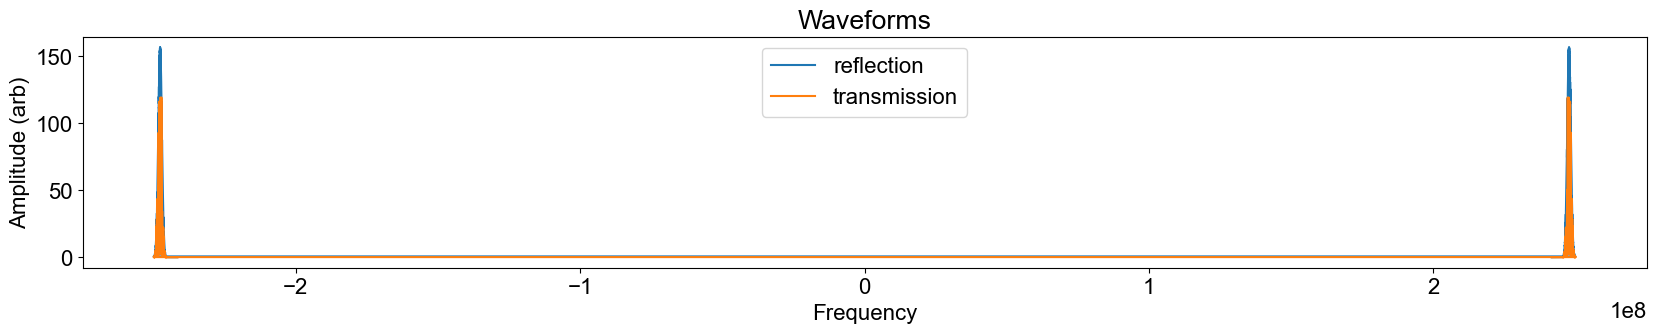

: 

In [ ]:
crop = slice(len(freqs)//2-1000, len(freqs)//2+1000)
tmm.plot_waveforms(f[crop], 
                   [reflection_fft_response[crop],transmission_fft_response[crop], ], 
                   labels=['reflection','transmission', ], 
                   ax=None, x_label="Frequency", y_label="Amplitude (arb)")

In [ ]:

transmitted_envelope = abs(signal.hilbert(transmitted_waveform))
reflected_envelope = abs(signal.hilbert(reflected_waveform))


/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<Axes: xlabel='Frequency', ylabel='Amplitude (arb)'>

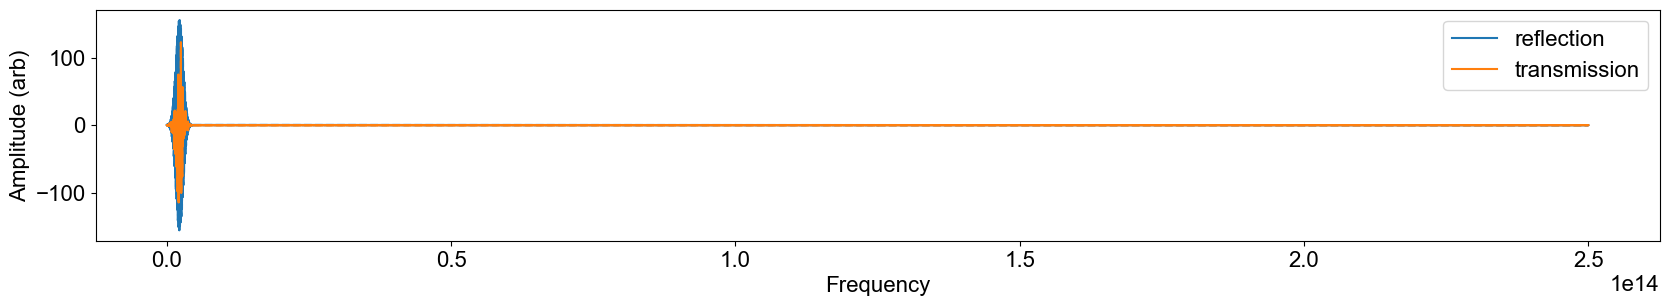

In [ ]:
tmm.plot_waveforms(freqs, 
                   [reflection_fft_response,transmission_fft_response, ], 
                   [reflection_fft_response, transmission_fft_response, ], 
                   labels=['reflection','transmission', ], 
                   ax=None, x_label="Frequency", y_label="Amplitude (arb)")

<Axes: xlabel='Time (μs)', ylabel='Amplitude (mV)'>

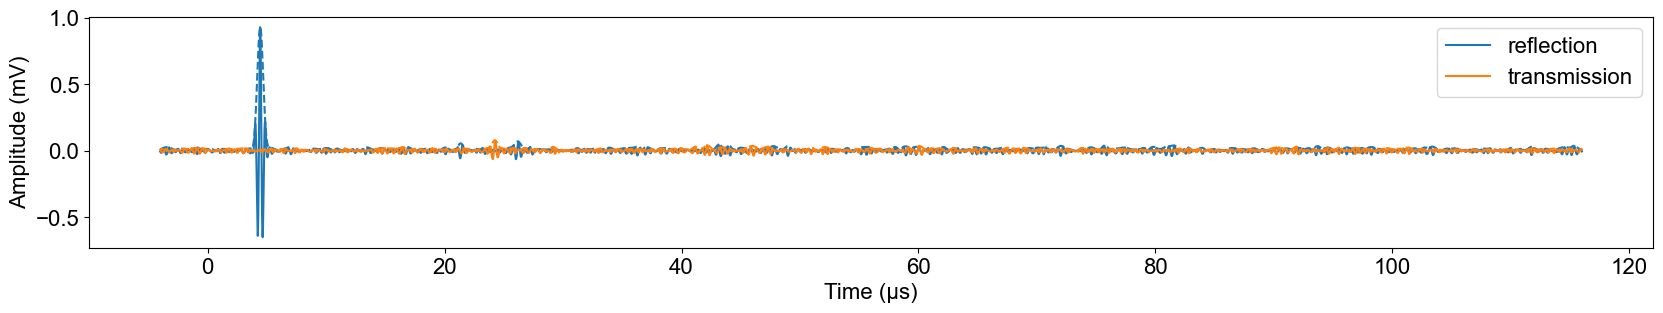

In [ ]:
tmm.plot_waveforms(t, 
                   [reflected_waveform,transmitted_waveform, ], 
                   [reflected_envelope, transmitted_envelope, ], 
                    labels=['reflection','transmission', ],
                    ax=None)

### Look at transmitted and reflected waveform after each interface
- Transmitted: $\psi_{f,r} = \frac{1}{T_{11}} \psi_{i,r}$ 
- Reflected: $\psi_{i,l} = \frac{T_{12}}{T_{11}} \psi_{i,r}$


### 1 layer

In [47]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,10000-2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))
fft_ = np.fft.fftshift(np.fft.rfft(input_waveform))
freqs = np.fft.fftshift(np.fft.rfftfreq(len(t), dt))

/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonic_ml/src/ultrasonic_ml/models/tmm_np.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  


<Axes: xlabel='Time (μs)', ylabel='Amplitude (mV)'>

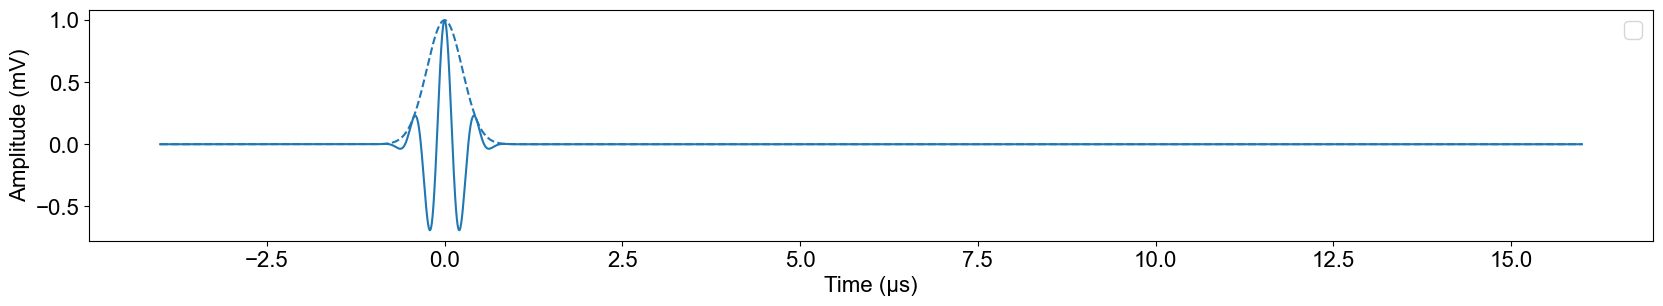

In [50]:
tmm.plot_waveforms(t, [input_waveform], [input_envelope], labels=None, ax=None, )

/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonic_ml/src/ultrasonic_ml/models/tmm_np.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  


<Axes: xlabel='Frequency (MHz)', ylabel='Amplitude (arb)'>

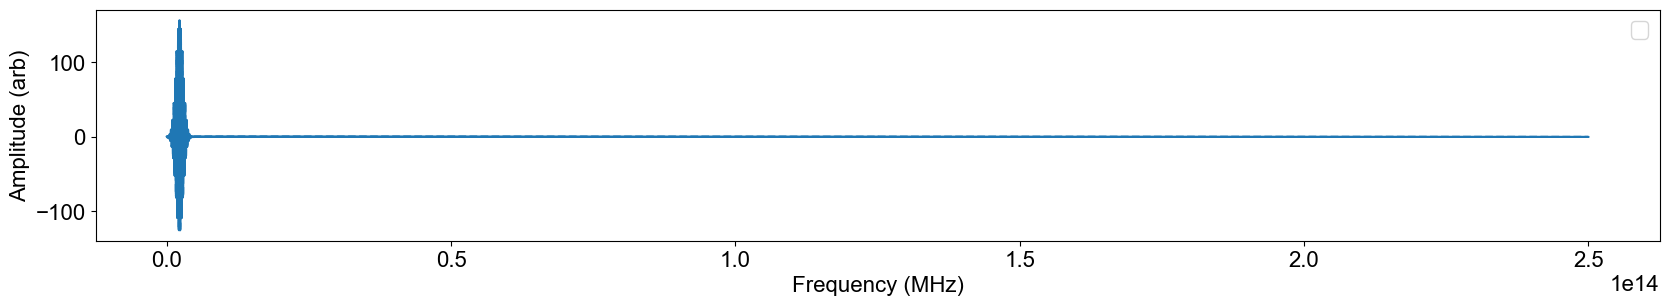

In [49]:
tmm.plot_waveforms(freqs, [fft_], [fft_], labels=None, ax=None, x_label="Frequency (MHz)", y_label="Amplitude (arb)")


In [51]:
current_layers_df = layers_df.iloc[:1]
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = tmm.propagate_waveform(input_waveform, dt, layers) 
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = tmm.reflect_waveform(input_waveform, dt, layers)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

In [ ]:
# TMM calculation of transmission and reflection coefficients
f = np.fft.rfftfreq(len(input_waveform), dt)
H_t = tmm.transmission_response(f, layers)
transmission_fft_response = H_t * fft_

H_r = tmm.reflection_response(f, layers)
reflection_fft_response = H_r * fft_


/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<Axes: xlabel='Frequency (MHz)', ylabel='Amplitude (arb)'>

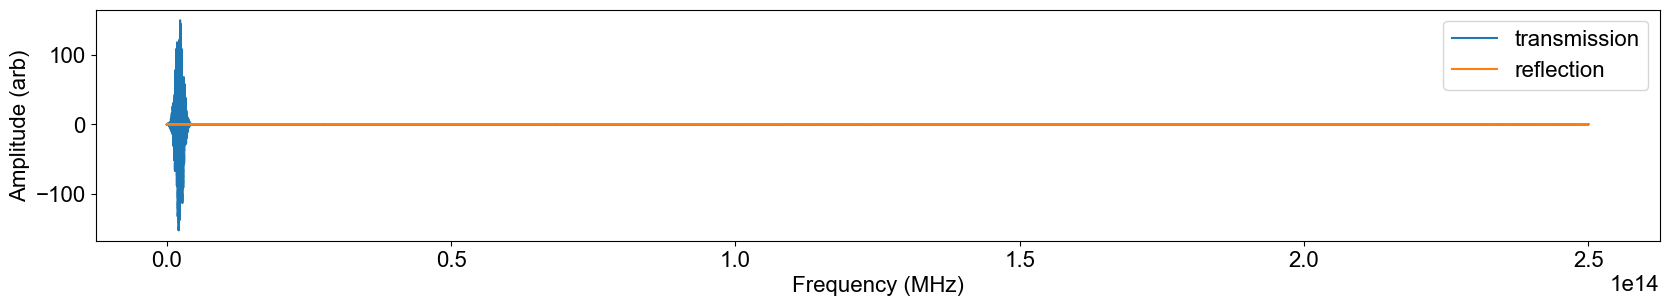

In [53]:
tmm.plot_waveforms(freqs, 
                   [transmission_fft_response, reflection_fft_response], 
                   [transmission_fft_response, reflection_fft_response], 
                   labels=['transmission', 'reflection'], 
                   ax=None, x_label="Frequency (MHz)", y_label="Amplitude (arb)")

##### Take a look at the time delays in the transmitted waveform. 
- The first peak should correspond to the theoretical transmitted time delay through the layers. 
- There is no reflection yet.
- Differences may be attributed to the time resolution, or numerical errors


In [9]:
import ultrasonic_ml.models.tmm_np as tmm

In [10]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
paths = tmm.generate_acoustic_paths(num_layers=len(current_layers_df), max_order=5)
tmm.print_paths(paths, return_paths=False)

Transmission: 0 | Path: 0 -> exit


In [11]:
tmm.compare_peak_times(t, layers_df, 
                       transmitted_envelope, reflected_envelope, 
                       paths)

Transmitted tof: (TMM peaks,	theoretical)
	0:	(2.2200e-06,	2.2194e-06)
Reflected tof: (TMM peaks,	theoretical)


In [ ]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope, 
                                          layers=list(current_layers_df.index))

/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonic_ml/src/ultrasonic_ml/models/tmm_np.py:967: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  slider = Slider(ax[2], '', 0, len(acoustic_paths)-1,


: 

##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment. 
- ([wiki article](https://en.wikipedia.org/wiki/Transfer-matrix_method_(optics)#Acoustic_waves)), ([using impedances](https://www.nde-ed.org/Physics/Waves/reflectiontransmission.xhtml)) 
    - NOTE: Need to double check why there is mismatch in the powers. Is it because of the fft/ ifft? Or other mistake? Does the input need an imaginary component?
- Total power $(P)$ must be conserved: 
    $$ P_{in} = P_{t} + P_{r} \text{\ where \ } P_{t} = \left\lvert \frac{1}{T_{11}} \right\rvert ^2 \text{\ and \ } P_{r} = \left\lvert \frac{T_{21}}{T_{11}} \right\rvert ^2 $$
- aka:
    $$1 = \left\lvert R \right\rvert ^2 + \left\lvert T \right\rvert ^2 = P_{r}/P_{in} + P_{t}/P_{in}$$

In [27]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,1.0000,0.0000,1.0000
1,Waveforms,1.0000,0.0000,1.0000


### 2 layers + sanity checks

In [7]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,10000-2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

In [8]:
current_layers_df = layers_df.iloc[:2]
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = tmm.propagate_waveform(input_waveform, dt, layers) 
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = tmm.reflect_waveform(input_waveform, dt, layers)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

##### Take a look at the time delays in the transmitted waveform. 

In [9]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
paths = tmm.generate_acoustic_paths(num_layers=2, max_order=4)
tmm.print_paths(paths, return_paths=False)

Transmission: 0 | Path: 0 -> 1 -> exit
Reflection: 1 | Path: 0 -> R(0|1) -> 0 -> exit


In [10]:
tmm.compare_peak_times(t, layers_df, 
                       transmitted_envelope, reflected_envelope, 
                       paths)

Transmitted tof: (TMM peaks,	theoretical)
	0:	(7.1940e-06,	7.1933e-06)
Reflected tof: (TMM peaks,	theoretical)
	0:	(4.4380e-06,	4.4388e-06)


In [11]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope,
                                          layers=list(current_layers_df.index))

##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment. 

In [35]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,3.7550,0.8794,4.6344
1,Waveforms,3.7550,0.8794,4.6344


### 3 layers + sanity checks

In [14]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,20000+2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

In [15]:
current_layers_df = layers_df.iloc[:3]
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = tmm.propagate_waveform(input_waveform, dt, layers) 
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = tmm.reflect_waveform(input_waveform, dt, layers)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

ValueError: x must be real.

##### Take a look at the time delays in the transmitted waveform. 


In [26]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
# Odd orders yield more reflection paths, even orders are transmission paths
paths = tmm.generate_acoustic_paths(num_layers=4, max_order=3)
paths.sort(key=lambda x: tmm.theoretical_path_time(x, layers_df))
tmm.print_paths(paths, return_paths=False)

generate_acoustic_paths took 0.0001 seconds
Transmission: 0 | Path: 0 -> 1 -> 2 -> 3 -> exit
Transmission: 2 | Path: 0 -> 1 -> 2 -> R(2|3) -> 2 -> R(1|2) -> 2 -> 3 -> exit
Transmission: 2 | Path: 0 -> 1 -> R(1|2) -> 1 -> R(0|1) -> 1 -> 2 -> 3 -> exit
Transmission: 2 | Path: 0 -> 1 -> 2 -> R(2|3) -> 2 -> 1 -> R(0|1) -> 1 -> 2 -> 3 -> exit
Reflection: 1 | Path: 0 -> R(0|1) -> 0 -> exit
Reflection: 1 | Path: 0 -> 1 -> R(1|2) -> 1 -> 0 -> exit
Reflection: 1 | Path: 0 -> 1 -> 2 -> R(2|3) -> 2 -> 1 -> 0 -> exit
Reflection: 3 | Path: 0 -> 1 -> R(1|2) -> 1 -> R(0|1) -> 1 -> R(1|2) -> 1 -> 0 -> exit
Reflection: 3 | Path: 0 -> 1 -> 2 -> R(2|3) -> 2 -> R(1|2) -> 2 -> R(2|3) -> 2 -> 1 -> 0 -> exit
Reflection: 3 | Path: 0 -> 1 -> R(1|2) -> 1 -> R(0|1) -> 1 -> 2 -> R(2|3) -> 2 -> 1 -> 0 -> exit
Reflection: 3 | Path: 0 -> 1 -> 2 -> R(2|3) -> 2 -> 1 -> R(0|1) -> 1 -> R(1|2) -> 1 -> 0 -> exit
Reflection: 3 | Path: 0 -> 1 -> 2 -> R(2|3) -> 2 -> 1 -> R(0|1) -> 1 -> 2 -> R(2|3) -> 2 -> 1 -> 0 -> exit


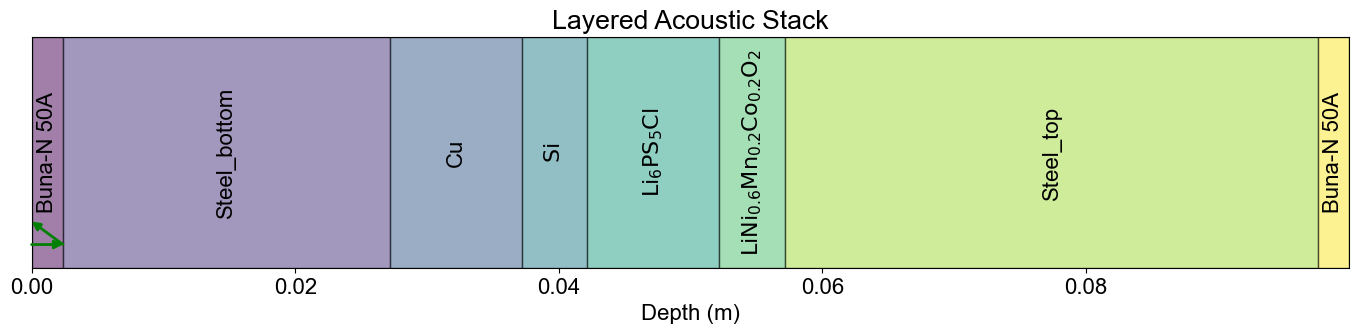

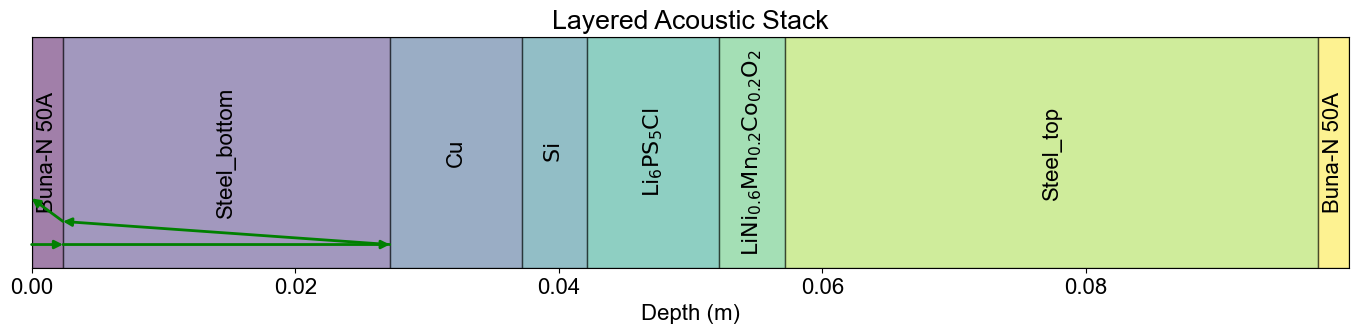

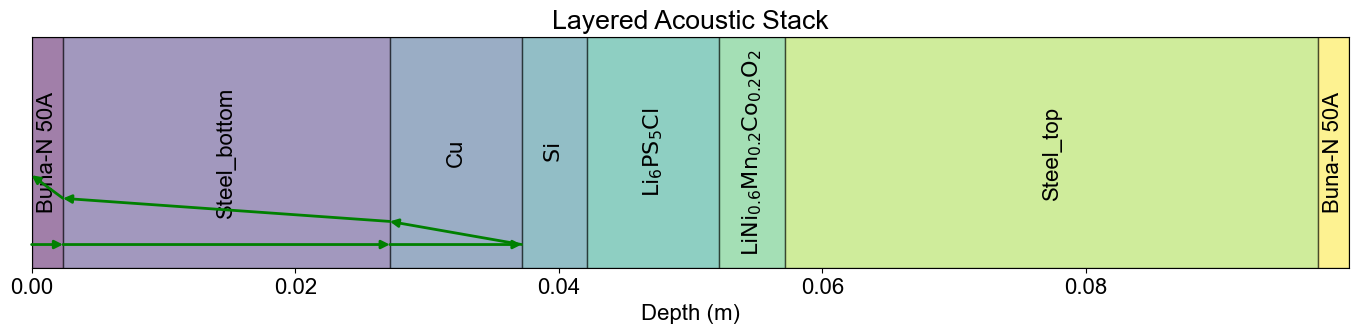

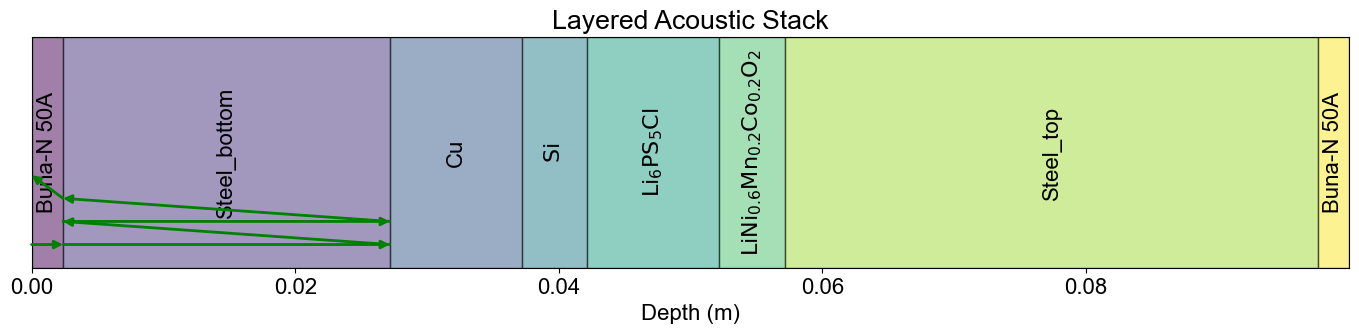

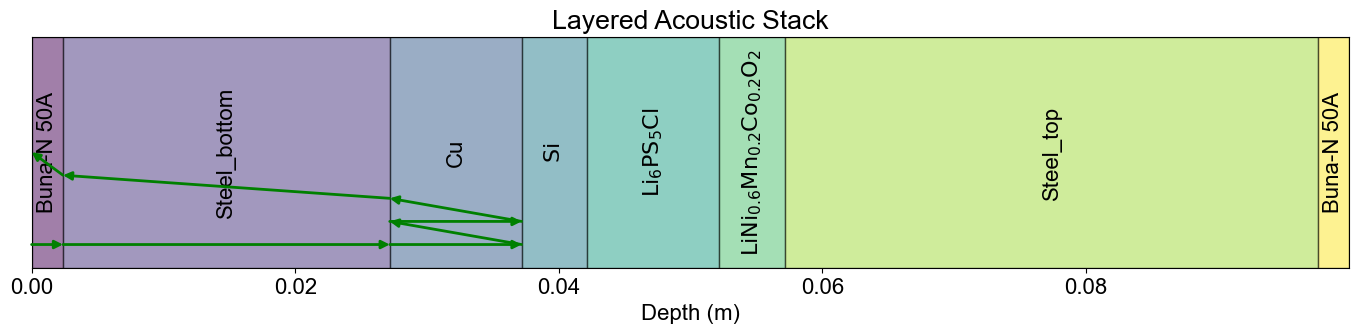

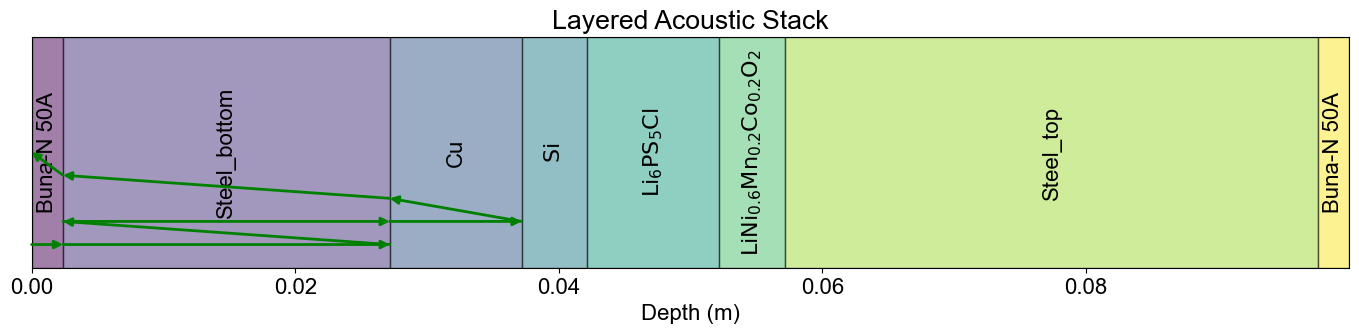

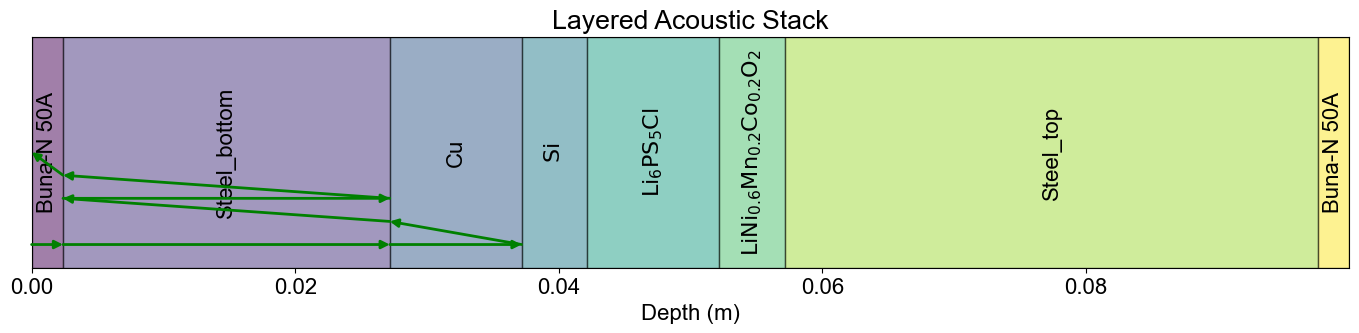

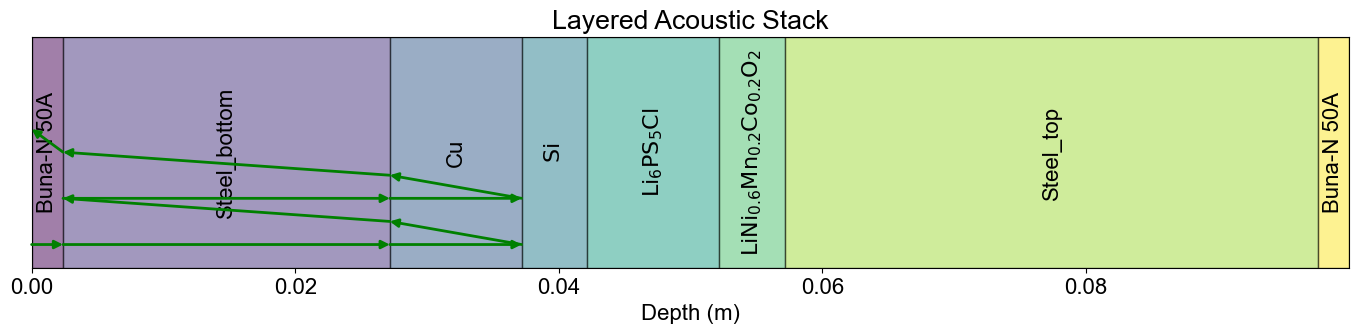

In [29]:
paths_ = [path for path in paths if path[0]=='Reflection']


In [ ]:
for path in paths_:
    fig, ax = tmm.plot_layers(layers_df )
    tmm.plot_acoustic_path(layers_df, path, ax,
                            y_start=0.1, y_step=0.1,)

In [21]:
tmm.compare_peak_times(t, layers_df, 
                       transmitted_envelope, reflected_envelope, 
                       paths)

Transmitted tof: (TMM peaks,	theoretical)
	0:	(1.9400e-06,	1.0047e-05)
	1:	(1.0048e-05,	1.9995e-05)
	2:	(1.9996e-05,	2.9943e-05)
Reflected tof: (TMM peaks,	theoretical)
	0:	(4.4380e-06,	4.4388e-06)
	1:	(1.4386e-05,	1.4387e-05)


In [22]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope,
                                          layers=list(current_layers_df.index))

##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment. 

In [41]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,3.0087,0.8796,3.8883
1,Waveforms,3.0086,0.8796,3.8882


### 4 layers (20000 samples)

In [23]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,20000+2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

In [24]:
current_layers_df = layers_df.iloc[:4]
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = tmm.propagate_waveform(input_waveform, dt, layers) 
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = tmm.reflect_waveform(input_waveform, dt, layers)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

##### Take a look at the time delays in the transmitted waveform. 

In [25]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
# Odd orders yield more reflection paths, even orders are transmission paths
paths = tmm.generate_acoustic_paths(num_layers=len(list(current_layers_df.index)), max_order=5)
paths.sort(key=lambda x: tmm.theoretical_path_time(x, layers_df))

In [26]:
# tmm.print_paths(paths, return_paths=False)

In [27]:
tmm.compare_peak_times(t, layers_df, 
                       transmitted_envelope, reflected_envelope, 
                       paths)

Transmitted tof: (TMM peaks,	theoretical)
	0:	(3.9200e-06,	1.0664e-05)
	1:	(1.0664e-05,	1.6372e-05)
	2:	(1.6370e-05,	2.0612e-05)
	3:	(2.0612e-05,	2.2080e-05)
	4:	(2.6320e-05,	2.6320e-05)
	5:	(3.0558e-05,	3.0560e-05)
	6:	(3.2026e-05,	3.2028e-05)
	7:	(3.6268e-05,	3.6268e-05)
	8:	(4.1976e-05,	4.1976e-05)
Reflected tof: (TMM peaks,	theoretical)
	0:	(4.4380e-06,	4.4388e-06)
	1:	(1.4384e-05,	1.4387e-05)
	2:	(2.0094e-05,	2.0095e-05)


In [28]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope,
                                          layers=list(current_layers_df.index))

##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment.

In [56]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,1.7716,0.8806,2.6522
1,Waveforms,1.7711,0.8806,2.6518


### 4 layers (40000 sampling points)

#### Problem: many complex secondary reflection and "ringing" 
The power in the TMM generate waveform is higher than expected. Extending the time axis helps a little.
- TODO: try transforms other than fft - 
    - Fourier Transform - Represents the magnitude and phase
        - Discrete Fourier Transform - for discrete system
    - Laplace Transforms - Represents the magnitude, phase, and dampening of a continuous system.
        - Z transform - Represents the magnitude, phase, and dampening of a discrete system. (is the dampening of individual frequency bins? to preven the sharp "stepping" of having timeframe cut off.)
    - [Chirp Z-Transform](https://en.wikipedia.org/wiki/Chirp_Z-transform): 
        - [repository](https://github.com/garrettj403/CZT)- based on [Lawrence R. Rabiner, Ronald W. Schafer, and Charles M. Rader, "The chirp z-transform algorithm and its application," Bell Syst. Tech. J. 48, 1249-1292 (1969).](https://web.ece.ucsb.edu/Faculty/Rabiner/ece259/Reprints/015_czt.pdf)
    - [CWT] - using pytwavelets
    - [Ccontinuous Q transform](https://github.com/iphysresearch/CQT_toolbox_python)
  

In [29]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,40000+2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

In [30]:
current_layers_df = layers_df.iloc[:4]
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = tmm.propagate_waveform(input_waveform, dt, layers) 
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = tmm.reflect_waveform(input_waveform, dt, layers)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

##### Take a look at the time delays in the transmitted waveform. 

In [31]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
# Odd orders yield more reflection paths, even orders are transmission paths
paths = tmm.generate_acoustic_paths(num_layers=len(list(current_layers_df.index)), max_order=7)
paths.sort(key=lambda x: tmm.theoretical_path_time(x, layers_df))

In [32]:
# tmm.print_paths(paths, return_paths=False)

In [33]:
tmm.compare_peak_times(t, layers_df, 
                       transmitted_envelope, reflected_envelope, 
                       paths)

Transmitted tof: (TMM peaks,	theoretical)
	0:	(1.0664e-05,	1.0664e-05)
	1:	(1.6372e-05,	1.6372e-05)
	2:	(2.0612e-05,	2.0612e-05)
	3:	(2.6320e-05,	2.2080e-05)
	4:	(3.0562e-05,	2.6320e-05)
	5:	(3.2026e-05,	2.7788e-05)
	6:	(3.6268e-05,	3.0560e-05)
	7:	(4.1976e-05,	3.2028e-05)
	8:	(5.1924e-05,	3.6268e-05)
	9:	(5.7632e-05,	3.7736e-05)
Reflected tof: (TMM peaks,	theoretical)
	0:	(4.4380e-06,	4.4388e-06)
	1:	(1.4384e-05,	1.4387e-05)
	2:	(2.0094e-05,	2.0095e-05)


In [34]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope,
                                          layers=list(current_layers_df.index))

##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment.

In [67]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,1.7715,0.8806,2.6521
1,Waveforms,1.7703,0.8807,2.6510


### 5 layers (40000 samples)

In [ ]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,40000+2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

In [77]:
current_layers_df = layers_df.iloc[:5]
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = tmm.propagate_waveform(input_waveform, dt, layers) 
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = tmm.reflect_waveform(input_waveform, dt, layers)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

##### Take a look at the time delays in the transmitted waveform. 

In [70]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
# Odd orders yield more reflection paths, even orders are transmission paths
paths = tmm.generate_acoustic_paths(num_layers=len(list(current_layers_df.index)), max_order=7)
paths.sort(key=lambda x: tmm.theoretical_path_time(x, layers_df))

In [71]:
# tmm.print_paths(paths, return_paths=False)

In [72]:
tmm.compare_peak_times(t, layers_df, 
                       transmitted_envelope, reflected_envelope, 
                       paths)

Transmitted tof: (TMM peaks,	theoretical)
	0:	(1.4400e-07,	1.3111e-05)
	1:	(1.3700e-06,	1.4344e-05)
	2:	(7.0840e-06,	1.5578e-05)
	3:	(1.3110e-05,	1.6812e-05)
	4:	(1.4350e-05,	1.8819e-05)
	5:	(1.7016e-05,	2.0053e-05)
	6:	(1.8816e-05,	2.1286e-05)
	7:	(2.0052e-05,	2.2520e-05)
	8:	(2.3062e-05,	2.3058e-05)
	9:	(2.8766e-05,	2.4292e-05)
	10:	(3.0000e-05,	2.4527e-05)
	11:	(3.1242e-05,	2.5526e-05)
	12:	(3.5706e-05,	2.5761e-05)
	13:	(3.6946e-05,	2.6994e-05)
	14:	(3.8714e-05,	2.8228e-05)
	15:	(3.9948e-05,	2.8766e-05)
	16:	(4.1210e-05,	3.0000e-05)
	17:	(4.4420e-05,	3.0235e-05)
	18:	(4.5656e-05,	3.1234e-05)
	19:	(4.6888e-05,	3.1469e-05)
	20:	(4.8132e-05,	3.2468e-05)
	21:	(5.1380e-05,	3.2702e-05)
	22:	(5.2596e-05,	3.3006e-05)
	23:	(5.5602e-05,	3.3936e-05)
	24:	(5.6830e-05,	3.4240e-05)
	25:	(5.8124e-05,	3.4475e-05)
	26:	(6.1310e-05,	3.5708e-05)
	27:	(6.2544e-05,	3.6942e-05)
	28:	(6.3772e-05,	3.8176e-05)
	29:	(6.5022e-05,	3.8714e-05)
	30:	(6.8274e-05,	3.9948e-05)
	31:	(6.9480e-05,	4.0183e-05)
	32:	(7.

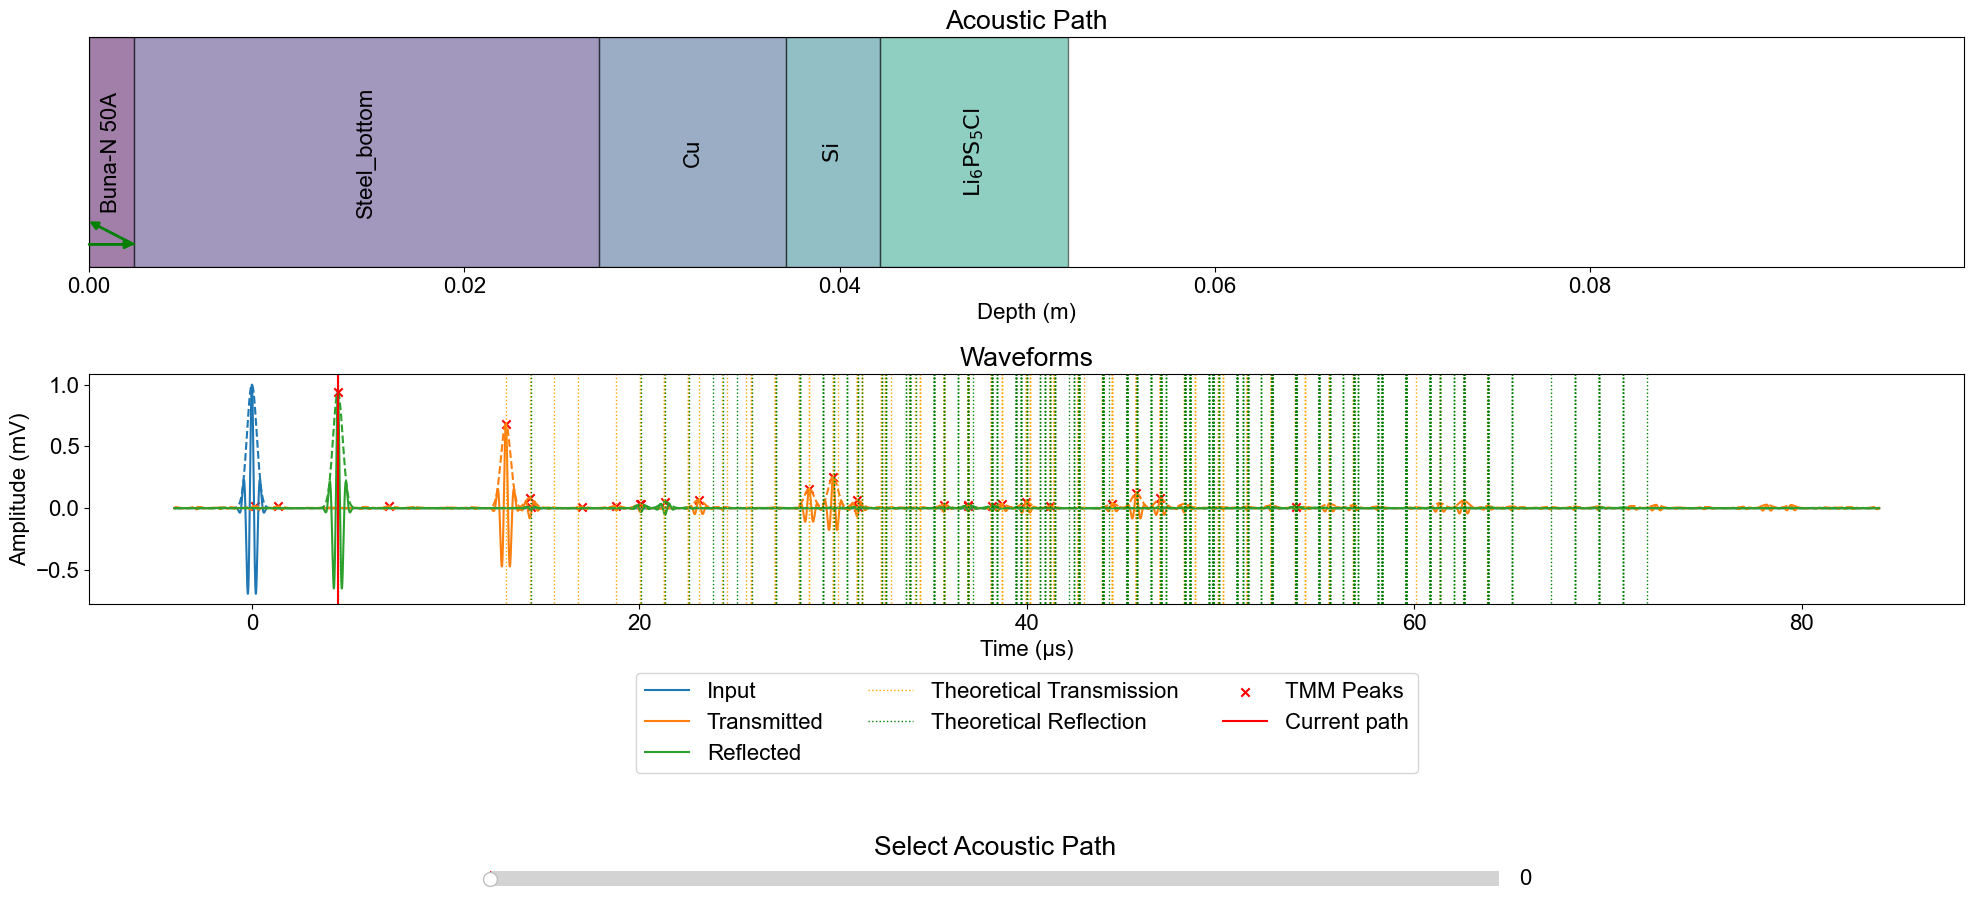

In [74]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope,
                                          layers=list(current_layers_df.index))

### 5 layers (60000 samples)

In [35]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,60000+2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

In [36]:
current_layers_df = layers_df.iloc[:5]
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = tmm.propagate_waveform(input_waveform, dt, layers) 
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = tmm.reflect_waveform(input_waveform, dt, layers)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

##### Take a look at the time delays in the transmitted waveform. 

In [37]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
# Odd orders yield more reflection paths, even orders are transmission paths
paths = tmm.generate_acoustic_paths(num_layers=len(list(current_layers_df.index)), max_order=11)
paths.sort(key=lambda x: tmm.theoretical_path_time(x, layers_df))

In [38]:
# tmm.print_paths(paths, return_paths=False)

In [39]:
# tmm.compare_peak_times(t, layers_df, 
#                        transmitted_envelope, reflected_envelope, 
#                        paths)

In [40]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope,
                                          layers=list(current_layers_df.index))

##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment.

In [75]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,0.6133,0.8851,1.4983
1,Waveforms,0.6153,0.8847,1.5000


### 6 layers

In [48]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,60000+2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

In [51]:
current_layers_df = layers_df.iloc[:6]
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = tmm.propagate_waveform(input_waveform, dt, layers) 
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = tmm.reflect_waveform(input_waveform, dt, layers)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

##### Take a look at the time delays in the transmitted waveform. 

In [62]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
# Odd orders yield more reflection paths, even orders are transmission paths
paths = tmm.generate_acoustic_paths(num_layers=len(list(current_layers_df.index)), max_order=9)
paths.sort(key=lambda x: tmm.theoretical_path_time(x, layers_df))

In [63]:
# tmm.print_paths(paths, return_paths=False)

In [64]:
# tmm.compare_peak_times(t, layers_df, 
#                        transmitted_envelope, reflected_envelope, 
#                        paths)

In [65]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope,
                                          layers=list(current_layers_df.index))

##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment.

In [61]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,2.3344,0.8969,3.2313
1,Waveforms,2.2450,0.9008,3.1459


### 7 layers

In [14]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,60000+2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

In [15]:
current_layers_df = layers_df.iloc[:7]
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = tmm.propagate_waveform(input_waveform, dt, layers) 
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = tmm.reflect_waveform(input_waveform, dt, layers)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

##### Take a look at the time delays in the transmitted waveform. 

In [17]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
# Odd orders yield more reflection paths, even orders are transmission paths
paths = tmm.generate_acoustic_paths(num_layers=len(list(current_layers_df.index)), max_order=7)
paths.sort(key=lambda x: tmm.theoretical_path_time(x, layers_df))

In [18]:
# tmm.print_paths(paths, return_paths=False)

In [19]:
# tmm.compare_peak_times(t, layers_df, 
#                        transmitted_envelope, reflected_envelope, 
#                        paths)

In [ ]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope,
                                          layers=list(current_layers_df.index))

: 

##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment.

In [ ]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,2.3344,0.8969,3.2313
1,Waveforms,2.2450,0.9008,3.1459


### 8 layers (full stack)

#### step by step

In [66]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,60000-2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))
fft_ = np.fft.fftshift(np.fft.rfft(input_waveform))
freqs = np.fft.fftshift(np.fft.rfftfreq(len(t), dt))

In [67]:
tmm.plot_waveforms(t, [input_waveform], [input_envelope], labels=None, ax=None, )

/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonic_ml/src/ultrasonic_ml/models/tmm_np.py:771: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


<Axes: xlabel='Time (μs)', ylabel='Amplitude (mV)'>

<Axes: xlabel='Frequency (MHz)', ylabel='Amplitude (arb)'>

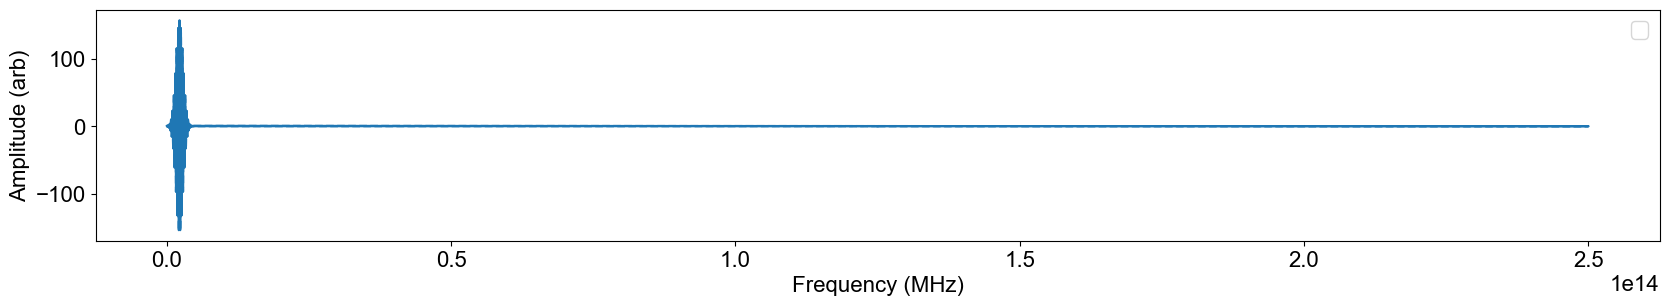

In [56]:
tmm.plot_waveforms(freqs, [fft_], [fft_], labels=None, ax=None, x_label="Frequency (MHz)", y_label="Amplitude (arb)")


In [ ]:
current_layers_df = layers_df
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form

# TMM calculation of transmission and reflection coefficients
f = np.fft.rfftfreq(len(input_waveform), dt)
H_t = tmm.transmission_response(f, layers)
transmission_fft_response = abs(H_t * fft_)

H_r = tmm.reflection_response(f, layers)
reflection_fft_response = abs(H_r * fft_)

transmitted_waveform = np.fft.ifft(transmission_fft_response * np.fft.rfft(input_waveform, axis=0), axis=0)
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = np.fft.ifft(reflection_fft_response * np.fft.rfft(input_waveform, axis=0), axis=0)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<Axes: xlabel='Frequency', ylabel='Amplitude (arb)'>

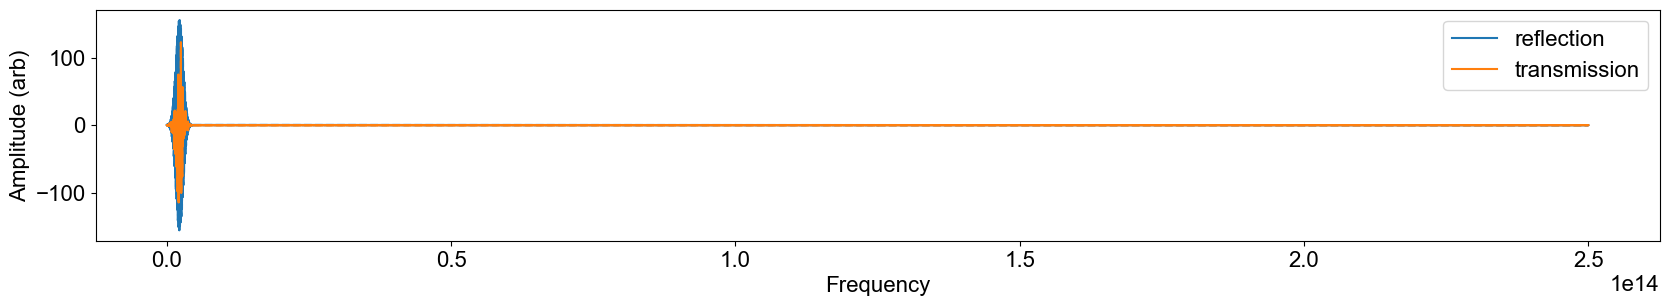

In [77]:
tmm.plot_waveforms(freqs, 
                   [reflection_fft_response,transmission_fft_response, ], 
                   [reflection_fft_response, transmission_fft_response, ], 
                   labels=['reflection','transmission', ], 
                   ax=None, x_label="Frequency", y_label="Amplitude (arb)")

<Axes: xlabel='Time (μs)', ylabel='Amplitude (mV)'>

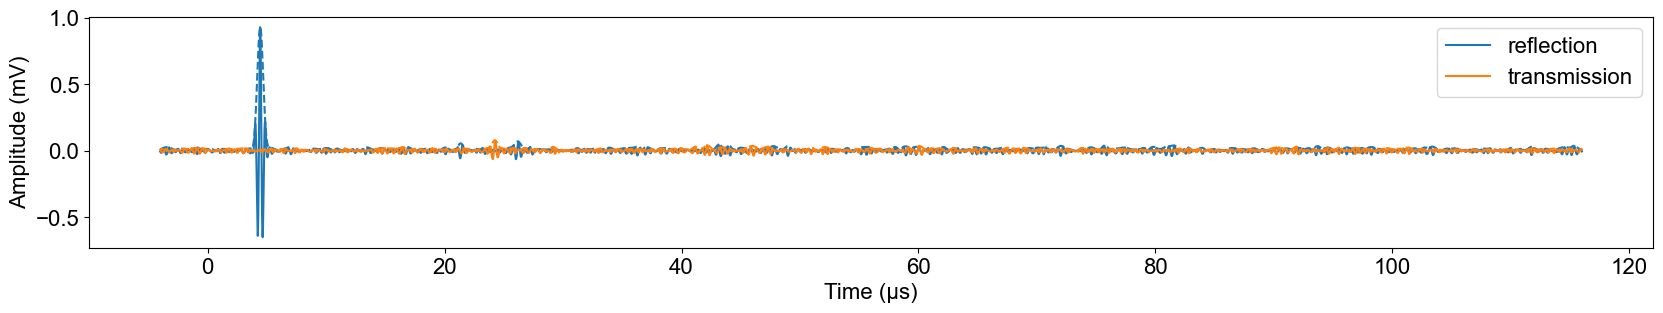

In [76]:
tmm.plot_waveforms(t, 
                   [reflected_waveform,transmitted_waveform, ], 
                   [reflected_envelope, transmitted_envelope, ], 
                    labels=['reflection','transmission', ],
                    ax=None)

#### show results

In [7]:
# Real Morlet input pulse. There are some negative times for the peak to be at 0
dt = 2e-9
t = np.arange(-2000,60000+2000) * dt
f0 = 2.25e6
t0 = 0

sigma = 0.25e-6
input_waveform = np.exp(-0.5 * ((t - t0) / sigma)**2) * np.cos(2 * np.pi * f0 * (t - t0))
input_envelope = np.abs(signal.hilbert(input_waveform))

In [8]:
current_layers_df = layers_df
layers = tmm.layers_from_df( current_layers_df ) # make in dictionary form
    
transmitted_waveform = tmm.propagate_waveform(input_waveform, dt, layers) 
transmitted_envelope = abs(signal.hilbert(transmitted_waveform))

reflected_waveform = tmm.reflect_waveform(input_waveform, dt, layers)
reflected_envelope = abs(signal.hilbert(reflected_waveform))

##### Take a look at the time delays in the transmitted waveform. 

In [9]:
# dfs style algorithm to generate all valid reflection and transmission paths up to a specified order
# first and last are not included in layer list because there are no interfaces
# Odd orders yield more reflection paths, even orders are transmission paths
paths = tmm.generate_acoustic_paths(num_layers=len(list(current_layers_df.index)), max_order=5)
paths.sort(key=lambda x: tmm.theoretical_path_time(x, layers_df))

In [10]:
# tmm.print_paths(paths, return_paths=False)

In [11]:
# tmm.compare_peak_times(t, layers_df, 
#                        transmitted_envelope, reflected_envelope, 
#                        paths)

In [12]:
tmm.plot_path_waveforms_theoretical_v_tmm_time_delays(layers_df, paths, t, 
                                          input_waveform, transmitted_waveform, reflected_waveform, 
                                          input_envelope, transmitted_envelope, reflected_envelope,
                                          layers=list(current_layers_df.index))

##### Take a look at the amplitudes of the waveforms. We are assuming 0 attenuation at the moment.

In [13]:
tmm.compare_tmm_waveform_coefficients(input_waveform, transmitted_waveform, reflected_waveform, layers, dt)

,calculate from,transmission coefficient,reflection coefficient,total
0,TMM,0.0435,0.9565,1.0000
1,Waveforms,0.0429,0.9571,1.0000
